# Predicción de Peso de Bebés al Nacer
### Versión 4.0
## Maestría en Analítica para la Inteligencia de Negocios — PUJ
### Métodos de Analítica II

**Objetivo:** Predecir si un bebé nacerá con bajo peso (≤ 5.5 libras) utilizando información disponible antes del nacimiento, comparando siete modelos de clasificación supervisada.

**Dataset:** `peso_bebes.csv` — registros de nacimientos en EE.UU. (~4.25M registros, 32 columnas originales).

**Variable objetivo:** `bebes_de_bajo_peso` (binaria) — `True` si el peso al nacer es ≤ 5.5 libras (umbral OMS ≈ 2,500g).

---

### Estructura del notebook

| Sección | Descripción |
|---------|-------------|
| 1 | Importación de librerías |
| 2 | Carga de datos |
| 3 | Entendimiento inicial (Data Understanding) |
| 4 | Eliminación de columnas sin valor analítico |
| 5 | Creación de la variable objetivo |
| 6 | Calidad de datos — duplicados |
| 7 | Tratamiento de valores nulos |
| 8 | Codificación de variables de raza |
| 9 | Asignación de tipos de datos |
| 10 | División Train / Test |
| 11 | Análisis Exploratorio (EDA) |
| 12 | Checkpoint del dataset |
| 13 | Muestra de desarrollo + preprocesamiento de raza |
| 14 | Pipeline de preprocesamiento compartido |
| 15 | Funciones de evaluación |
| 16–22 | Modelos (Ingenuo, M1–M6) |
| 23 | Feature Importance y SHAP |

---
## Sección 1 — Importación de Librerías

Todas las dependencias del proyecto centralizadas en un solo lugar.

> **Instalación previa** (correr una vez en terminal):
> ```
> pip install pandas numpy seaborn matplotlib scikit-learn xgboost shap
> ```

In [2]:
# --- Manipulación y análisis de datos ---
import pandas as pd
import numpy as np

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Modelado: división de datos ---
from sklearn.model_selection import train_test_split, GridSearchCV

# --- Modelado: preprocesamiento ---
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# --- Modelado: modelos ---
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import RFE
from xgboost import XGBClassifier

# --- Modelado: métricas ---
from sklearn.metrics import (roc_auc_score, roc_curve,
                              recall_score, classification_report)

# Configuración global de gráficos
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


---
## Sección 2 — Carga de Datos

Se carga el dataset desde el archivo CSV. Ajusta `ruta_archivo` si es necesario.

In [3]:
ruta_archivo = 'peso_bebes.csv'

df = pd.read_csv(ruta_archivo)
print(f"Datos cargados. Shape: {df.shape[0]:,} filas x {df.shape[1]} columnas.")

Datos cargados. Shape: 4,255,156 filas x 31 columnas.


---
## Sección 3 — Entendimiento Inicial de los Datos

Revisión rápida de estructura, tipos de datos y primeras filas para entender qué tenemos antes de cualquier transformación.

In [4]:
print("--- Primeras 5 filas ---")
display(df.head())

print("\n--- Info general del DataFrame ---")
df.info()

print("\n--- Conteo de tipos de datos ---")
print(df.dtypes.value_counts())

print("\n--- Valores únicos por columna ---")
print(df.nunique())

--- Primeras 5 filas ---


,source_year,year,month,day,wday,state,is_male,child_race,weight_pounds,plurality,...,alcohol_use,drinks_per_week,weight_gain_pounds,born_alive_alive,born_alive_dead,born_dead,ever_born,father_race,father_age,record_weight
0,2022,2022,4,NaN,5,NaN,False,NaN,6.437498,1,...,NaN,NaN,30.0,NaN,NaN,NaN,8.0,NaN,49,1
1,2022,2022,3,NaN,5,NaN,False,NaN,7.262027,1,...,NaN,NaN,99.0,NaN,NaN,NaN,8.0,NaN,45,1
2,2022,2022,12,NaN,2,NaN,True,NaN,6.000983,1,...,NaN,NaN,54.0,NaN,NaN,NaN,8.0,NaN,38,1
3,2022,2022,10,NaN,4,NaN,True,NaN,8.126239,1,...,NaN,NaN,30.0,NaN,NaN,NaN,8.0,NaN,39,1
4,2022,2022,11,NaN,4,NaN,False,NaN,7.312733,1,...,NaN,NaN,10.0,NaN,NaN,NaN,8.0,NaN,40,1



--- Info general del DataFrame ---
<class 'pandas.DataFrame'>
RangeIndex: 4255156 entries, 0 to 4255155
Data columns (total 31 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   source_year             int64  
 1   year                    int64  
 2   month                   int64  
 3   day                     float64
 4   wday                    int64  
 5   state                   float64
 6   is_male                 bool   
 7   child_race              float64
 8   weight_pounds           float64
 9   plurality               int64  
 10  apgar_1min              float64
 11  apgar_5min              float64
 12  mother_residence_state  float64
 13  mother_race             float64
 14  mother_age              int64  
 15  gestation_weeks         float64
 16  lmp                     int64  
 17  mother_married          bool   
 18  mother_birth_state      float64
 19  cigarette_use           object 
 20  cigarettes_per_day      float64
 21  alcoho

---
## Sección 4 — Eliminación de Columnas sin Valor Analítico

Se eliminan columnas en dos pasos:

**4a. Columnas constantes** — un solo valor único → aportan cero información al modelo.

**4b. Columnas con data leakage o irrelevantes:**

| Columna | Razón de eliminación |
|---------|----------------------|
| `month`, `wday` | Fecha de nacimiento — no disponible antes del parto |
| `apgar_1min`, `apgar_5min` | Score Apgar medido POST-nacimiento → leakage |
| `ever_born` | Redundante con otras variables |
| `lmp` | Redundante con `gestation_weeks`, muchos valores inválidos |
| `weight_pounds` | **⚠️ Leakage crítico** — es la fuente del target |
| `record_weight` | Variable de diseño muestral, no predictiva |

> **Data Leakage:** ocurre cuando el modelo recibe información que no estaría disponible en el momento de hacer una predicción real. `weight_pounds` define directamente el target (`peso <= 5.5`) — incluirlo sería darle la respuesta al modelo.

In [5]:
# --- 4a. Columnas constantes ---
cols_constantes = [col for col in df.columns if df[col].nunique() <= 1]
print(f"Columnas constantes a eliminar: {cols_constantes}")
df = df.drop(columns=cols_constantes)

# --- 4b. Columnas con leakage o sin valor ---
columns_to_drop = [
    'month', 'wday',
    'apgar_5min', 'apgar_1min',
    'ever_born', 'lmp',
    'weight_pounds',
    'record_weight'
]
columns_to_drop = [c for c in columns_to_drop if c in df.columns]
df = df.drop(columns=columns_to_drop)

print(f"Columnas eliminadas: {columns_to_drop}")
print(f"Shape tras limpieza: {df.shape}")

Columnas constantes a eliminar: ['source_year', 'year', 'day', 'state', 'child_race', 'apgar_1min', 'mother_residence_state', 'mother_birth_state', 'drinks_per_week', 'born_alive_alive', 'born_alive_dead', 'born_dead', 'record_weight']
Columnas eliminadas: ['month', 'wday', 'apgar_5min', 'ever_born', 'lmp', 'weight_pounds']
Shape tras limpieza: (4255156, 12)


---
## Sección 5 — Creación de la Variable Objetivo

La variable objetivo `bebes_de_bajo_peso` se crea como `True` si el peso al nacer es ≤ 5.5 libras (~2,500g), umbral de la OMS para bajo peso neonatal.

> **Orden crítico:** se crea el target **antes** de eliminar `weight_pounds`. Si se eliminara primero, no habría de dónde calcular el target. El script re-lee el CSV para garantizar este orden.

In [6]:
# Re-leer para aplicar el orden correcto: crear target → eliminar weight_pounds
df_raw = pd.read_csv(ruta_archivo)
df_raw = df_raw.drop(columns=[col for col in cols_constantes if col in df_raw.columns])

# Crear target PRIMERO
df_raw['bebes_de_bajo_peso'] = (df_raw['weight_pounds'] <= 5.5).astype(bool)

# Luego eliminar columnas (incluyendo weight_pounds)
columns_to_drop_final = [
    'month', 'wday', 'apgar_5min', 'apgar_1min',
    'ever_born', 'lmp', 'weight_pounds', 'record_weight'
]
columns_to_drop_final = [c for c in columns_to_drop_final if c in df_raw.columns]
df = df_raw.drop(columns=columns_to_drop_final)

print("--- Distribución del target 'bebes_de_bajo_peso' ---")
print(df['bebes_de_bajo_peso'].value_counts())
print(df['bebes_de_bajo_peso'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

--- Distribución del target 'bebes_de_bajo_peso' ---
bebes_de_bajo_peso
False    3919971
True      335185
Name: count, dtype: int64
bebes_de_bajo_peso
False    92.12%
True      7.88%
Name: proportion, dtype: str


---
## Sección 6 — Calidad de Datos: Duplicados

> **Importante:** el check se hace sobre `df_raw` (antes de eliminar columnas). Si se hiciera después del drop, columnas de baja cardinalidad como `is_male` (2 valores) o `plurality` (5 valores) generarían ~2.4M "falsos duplicados" por colisiones de combinaciones — un bug silencioso que inflaría artificialmente el conteo.

In [7]:
duplicados = df_raw.duplicated().sum()
print(f"Filas duplicadas en datos originales: {duplicados:,}")
if duplicados > 0:
    print(f"Representan el {duplicados/len(df_raw)*100:.2f}% del dataset")
    # Descomentar tras verificar manualmente:
    # df_raw = df_raw.drop_duplicates()
    # df = df_raw.drop(columns=columns_to_drop_final)
else:
    print("Sin duplicados en el dataset original. OK.")

Filas duplicadas en datos originales: 388
Representan el 0.01% del dataset


In [8]:
df_raw = df_raw.drop_duplicates()
df = df_raw.drop(columns=columns_to_drop_final)

---
## Sección 7 — Tratamiento de Valores Nulos

### ¿Por qué NO imputar con moda las variables con 65% de nulos?

`cigarette_use`, `alcohol_use` y `*_race` tienen exactamente el mismo porcentaje de nulos (~65%). Esto no es ruido aleatorio — es **missingness estructural**: esos campos simplemente no fueron recolectados en ciertos estados o años de reporte.

Imputar con moda (`False`) para 2.7M de registros inventaría datos: el modelo aprendería *"esta madre no fuma"* cuando en realidad *"no se sabe si fuma"*.

### Estrategia: indicadores binarios de missingness

Se crea una columna `_reported` por cada variable con missingness estructural:
- `cigarette_reported = 1` → el dato sí fue recolectado
- `cigarette_reported = 0` → el dato NO fue recolectado

Así el modelo puede aprender que "no reportado" tiene su propio patrón de riesgo.

### Casos especiales con lógica determinista

- `cigarettes_per_day`: si `cigarette_use == False` → cigarrillos = 0 con certeza
- `drinks_per_week`: si `alcohol_use == False` → bebidas = 0 con certeza
- `weight_gain_pounds`: análisis mostró diferencia de **4.93pp** entre registros con/sin dato (12.70% vs 7.77% de bajo peso) → el NaN es informativo

In [9]:
print("--- Valores nulos por columna ---")
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100
resumen_nulos = pd.DataFrame({'nulos': nulos, 'pct': pct_nulos})
print(resumen_nulos[resumen_nulos['nulos'] > 0].sort_values('pct', ascending=False))

# --- Indicadores binarios de missingness ---
if 'cigarette_use' in df.columns:
    df['cigarette_reported'] = df['cigarette_use'].notna().astype(int)
if 'alcohol_use' in df.columns:
    df['alcohol_reported'] = df['alcohol_use'].notna().astype(int)
if 'mother_race' in df.columns:
    df['race_reported'] = df['mother_race'].notna().astype(int)
if 'weight_gain_pounds' in df.columns:
    df['weight_gain_reported'] = df['weight_gain_pounds'].notna().astype(int)

print("\nIndicadores de missingness (proporción de registros CON dato):")
print(df[['cigarette_reported', 'alcohol_reported',
          'race_reported', 'weight_gain_reported']].mean().round(3))

# --- Imputaciones lógicas deterministas ---
if 'cigarette_use' in df.columns and 'cigarettes_per_day' in df.columns:
    cond = (df['cigarette_use'] == False) & (df['cigarettes_per_day'].isna())
    df.loc[cond, 'cigarettes_per_day'] = 0
    print(f"\nNaN restantes cigarettes_per_day: {df['cigarettes_per_day'].isna().sum():,}")

if 'alcohol_use' in df.columns and 'drinks_per_week' in df.columns:
    cond = (df['alcohol_use'] == False) & (df['drinks_per_week'].isna())
    df.loc[cond, 'drinks_per_week'] = 0
    print(f"NaN restantes drinks_per_week: {df['drinks_per_week'].isna().sum():,}")

print("\nNulos restantes por columna (se tratarán en el pipeline):")
nulos_post = df.isnull().sum()
print(nulos_post[nulos_post > 0])

--- Valores nulos por columna ---
                      nulos        pct
cigarettes_per_day  4113008  96.668208
father_race         2912297  68.447845
mother_race         2912297  68.447845
alcohol_use         2766336  65.017317
cigarette_use       2766336  65.017317
weight_gain_pounds    95003   2.232860
gestation_weeks        5807   0.136482

Indicadores de missingness (proporción de registros CON dato):
cigarette_reported      0.350
alcohol_reported        0.350
race_reported           0.316
weight_gain_reported    0.978
dtype: float64

NaN restantes cigarettes_per_day: 2,766,336

Nulos restantes por columna (se tratarán en el pipeline):
mother_race           2912297
gestation_weeks          5807
cigarette_use         2766336
cigarettes_per_day    2766336
alcohol_use           2766336
weight_gain_pounds      95003
father_race           2912297
dtype: int64


---
## Sección 8 — Codificación de Variables de Raza

Los códigos numéricos originales (1, 2, 4, 5...) se reemplazan por etiquetas descriptivas. Esto mejora la interpretabilidad y evita que el modelo trate los códigos como si tuvieran una jerarquía numérica real.

In [10]:
raza_dict = {
    1: 'White', 2: 'Negro', 3: 'Indio americano', 4: 'Chino',
    5: 'Japonés', 6: 'Hawaiian', 7: 'Filipino', 9: 'Desconocido/OTRO',
    18: 'Indio Asiático', 28: 'Coreano', 39: 'Samoan', 48: 'Vietnamita'
}

for col_raza in ['mother_race', 'father_race', 'child_race']:
    if col_raza in df.columns:
        df[col_raza] = df[col_raza].map(raza_dict)
        print(f"\nDistribución de {col_raza}:")
        print(df[col_raza].value_counts(dropna=False))


Distribución de mother_race:
mother_race
NaN                2941950
White               993040
Negro               262127
Indio americano      22546
Indio Asiático       12847
Filipino              8064
Chino                 7279
Coreano               2927
Vietnamita            1985
Japonés               1441
Hawaiian               562
Name: count, dtype: int64

Distribución de father_race:
father_race
NaN                3180490
White               844009
Negro               184795
Indio americano      15440
Indio Asiático       12785
Chino                 6266
Filipino              5475
Coreano               2515
Vietnamita            1664
Japonés                891
Hawaiian               438
Name: count, dtype: int64


---
## Sección 9 — Asignación de Tipos de Datos

Asignar el tipo correcto a cada columna mejora el rendimiento y evita errores en los modelos. Se usa `Int64` (nullable integer de pandas) para columnas enteras con NaN — el tipo `int64` estándar no admite valores nulos.

In [11]:
# Variables categóricas nominales
categorical_cols = ['mother_race', 'father_race', 'child_race',
                    'state', 'mother_residence_state', 'mother_birth_state']
categorical_cols = [c for c in categorical_cols if c in df.columns]
df[categorical_cols] = df[categorical_cols].astype('category')

# Variables enteras con NaN → Int64 (nullable)
int_features = ['gestation_weeks', 'mother_age', 'cigarettes_per_day',
                'father_age', 'plurality', 'born_alive_alive',
                'born_alive_dead', 'born_dead', 'drinks_per_week']
int_features = [c for c in int_features if c in df.columns]
df[int_features] = df[int_features].apply(lambda x: x.astype('Int64'))

print("--- Tipos de datos finales ---")
df.info()

--- Tipos de datos finales ---
<class 'pandas.DataFrame'>
Index: 4254768 entries, 0 to 4255155
Data columns (total 17 columns):
 #   Column                Dtype   
---  ------                -----   
 0   is_male               bool    
 1   plurality             Int64   
 2   mother_race           category
 3   mother_age            Int64   
 4   gestation_weeks       Int64   
 5   mother_married        bool    
 6   cigarette_use         object  
 7   cigarettes_per_day    Int64   
 8   alcohol_use           object  
 9   weight_gain_pounds    float64 
 10  father_race           category
 11  father_age            Int64   
 12  bebes_de_bajo_peso    bool    
 13  cigarette_reported    int64   
 14  alcohol_reported      int64   
 15  race_reported         int64   
 16  weight_gain_reported  int64   
dtypes: Int64(5), bool(3), category(2), float64(1), int64(4), object(2)
memory usage: 462.6+ MB


---
## Sección 10 — División Train / Test

La división se hace **antes del EDA** para evitar data leakage en el análisis exploratorio. Solo se analiza `X_train`, simulando el escenario real donde el test es "futuro desconocido".

Se usa `stratify=y` para garantizar que la proporción de positivos (~7.88%) se mantenga idéntica en ambos conjuntos — crítico con clases desbalanceadas.

| Conjunto | Registros | % Bajo peso |
|----------|-----------|-------------|
| Train (70%) | ~2.97M | 7.88% |
| Test (30%) | ~1.27M | 7.88% |

In [12]:
y = df['bebes_de_bajo_peso']
X = df.drop(columns=['bebes_de_bajo_peso'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]:,} registros | Test: {X_test.shape[0]:,} registros")
print("\nDistribución target en Train:")
print(y_train.value_counts(normalize=True).mul(100).round(2))
print("\nDistribución target en Test:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Train: 2,978,337 registros | Test: 1,276,431 registros

Distribución target en Train:
bebes_de_bajo_peso
False    92.13
True      7.87
Name: proportion, dtype: float64

Distribución target en Test:
bebes_de_bajo_peso
False    92.13
True      7.87
Name: proportion, dtype: float64


---
## Sección 11 — Análisis Exploratorio de Datos (EDA)

Se trabaja **exclusivamente sobre `X_train`** para no contaminar el test set. Se usa una muestra de 100k registros por eficiencia computacional.

Visualizando 10 variables numéricas...


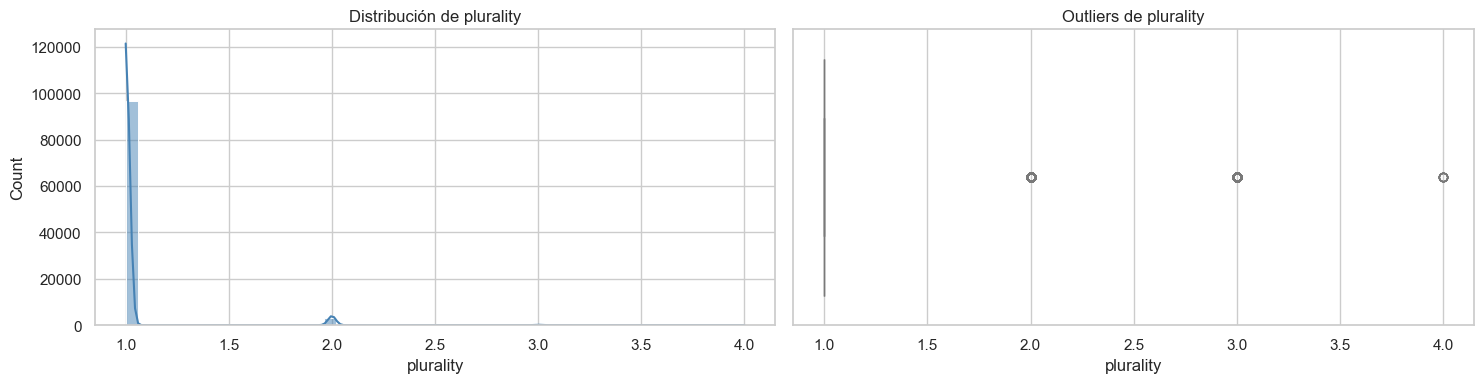

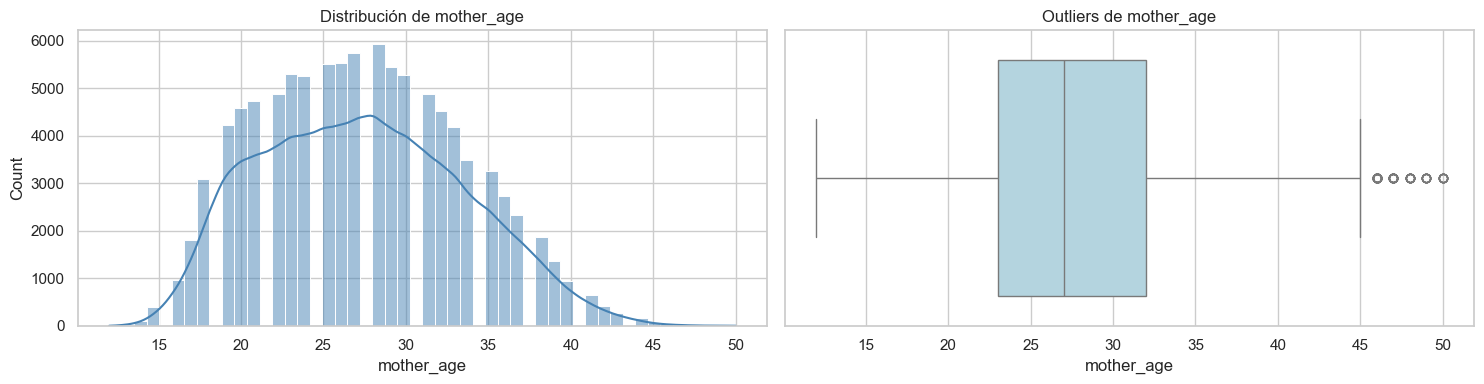

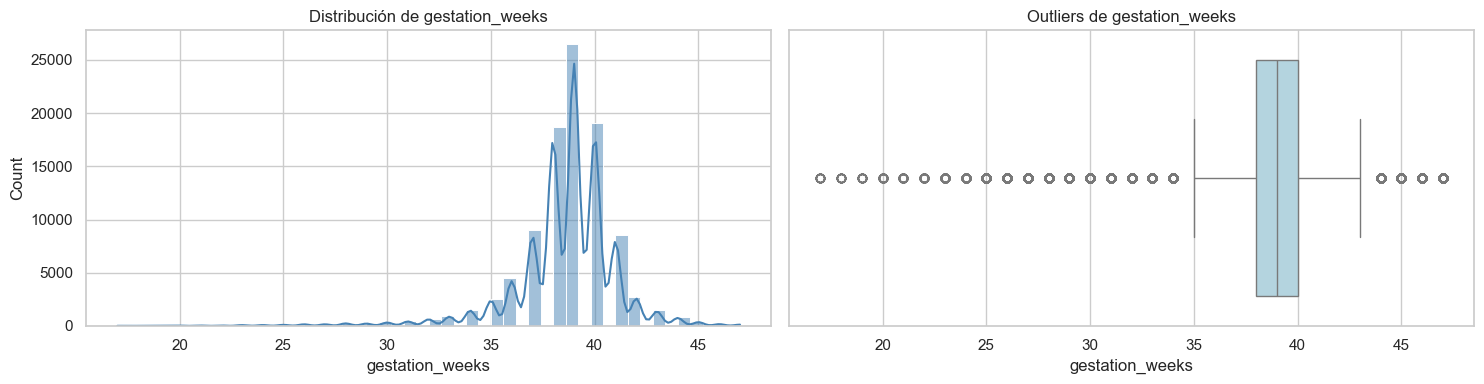

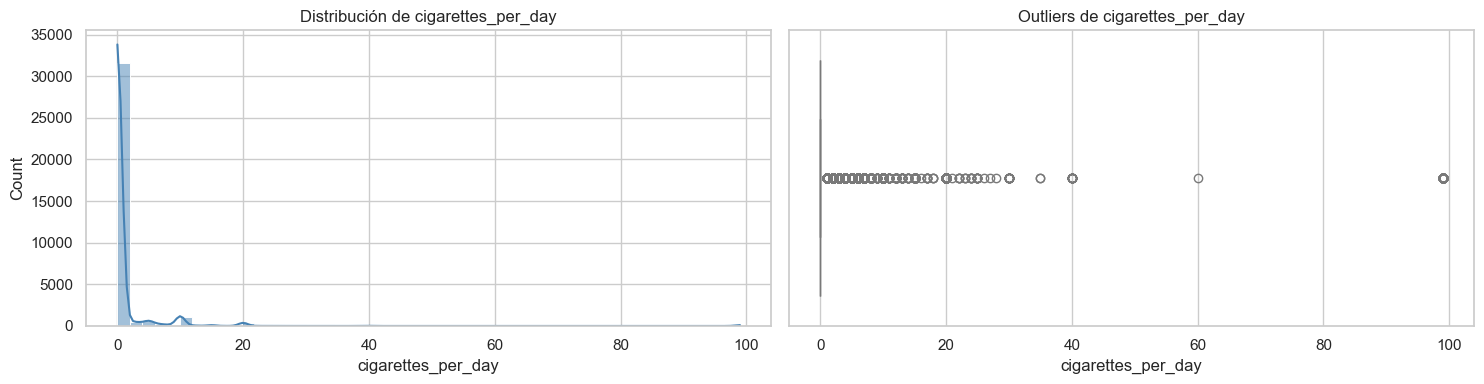

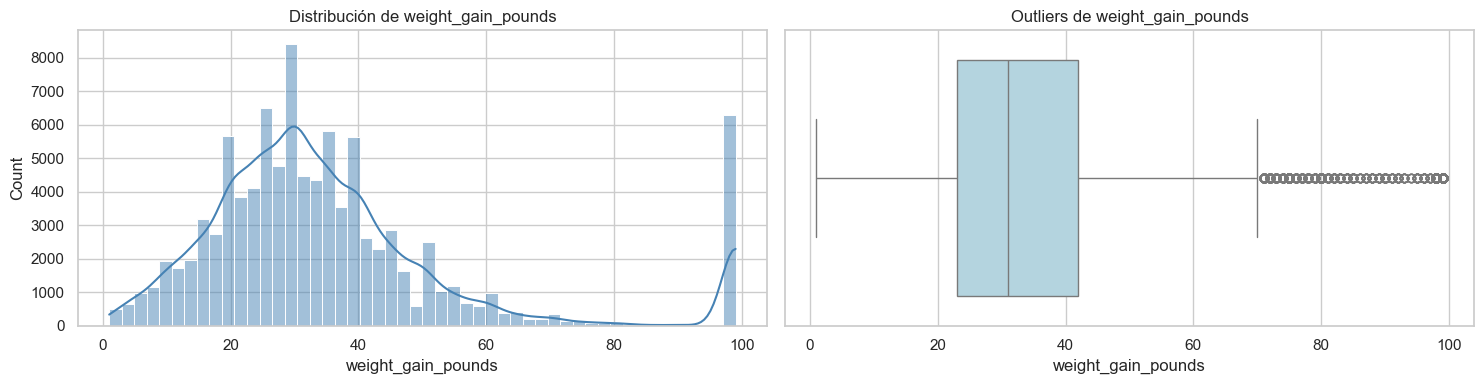

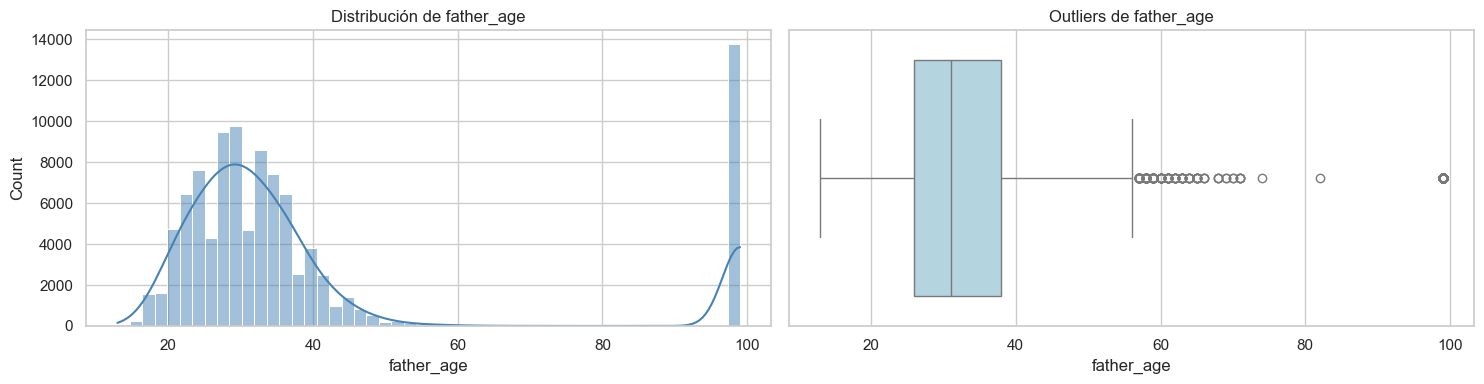

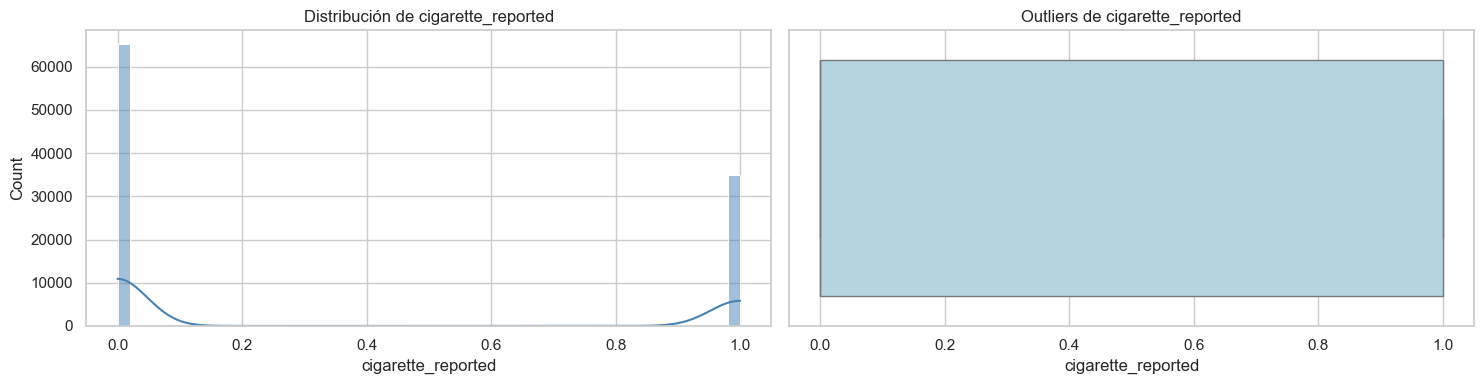

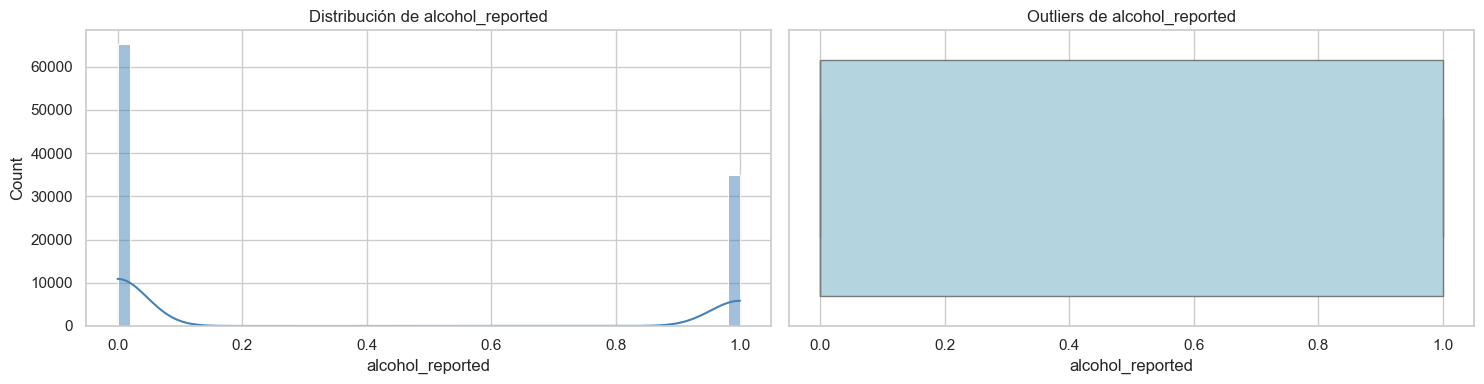

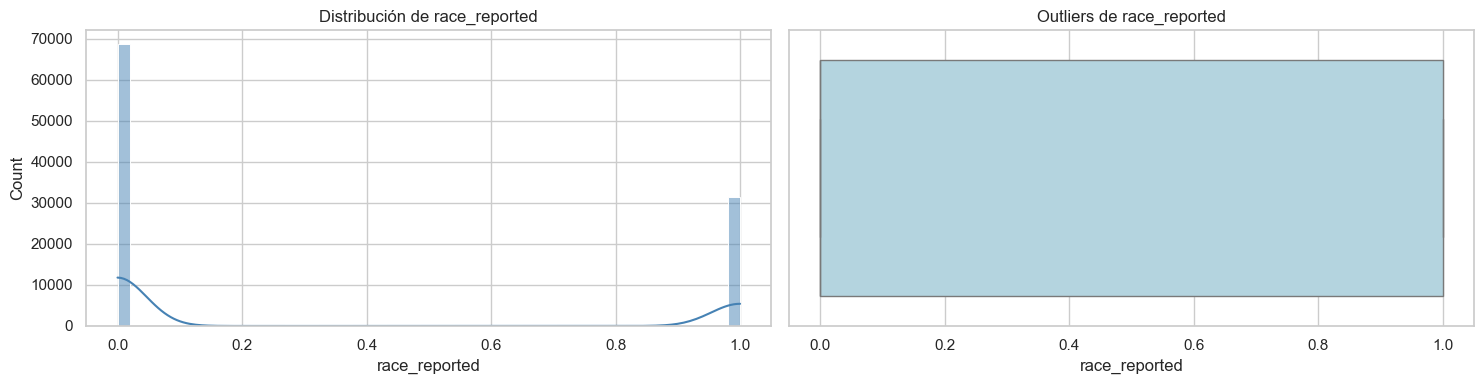

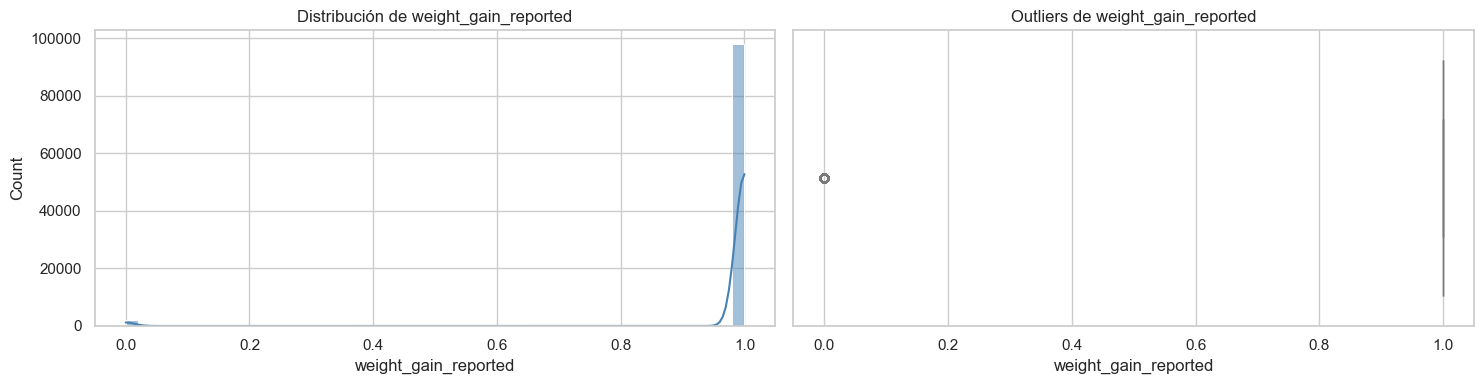


Visualizando 6 variables categóricas/booleanas...


C:\Users\eoar9\AppData\Local\Temp\ipykernel_19996\1353024509.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_muestra, y=col, order=top_cats, palette='viridis')


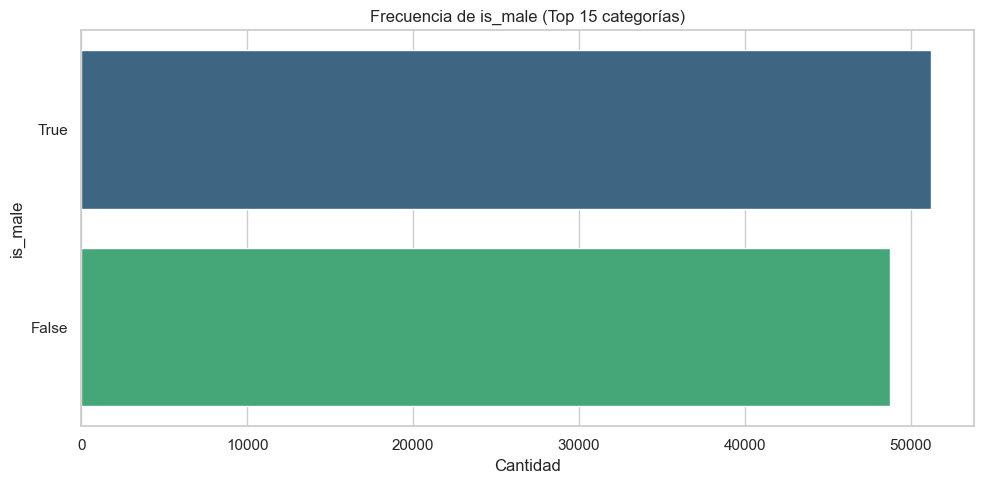

C:\Users\eoar9\AppData\Local\Temp\ipykernel_19996\1353024509.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_muestra, y=col, order=top_cats, palette='viridis')


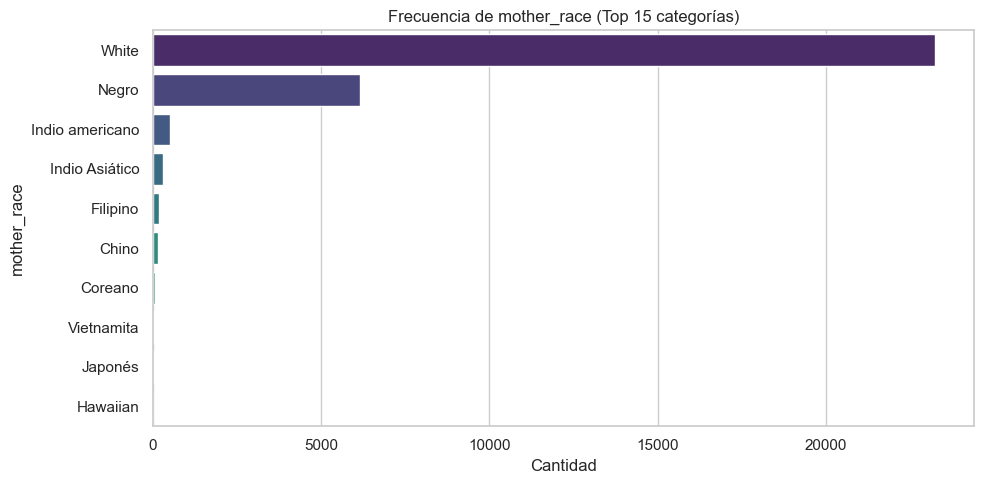

C:\Users\eoar9\AppData\Local\Temp\ipykernel_19996\1353024509.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_muestra, y=col, order=top_cats, palette='viridis')


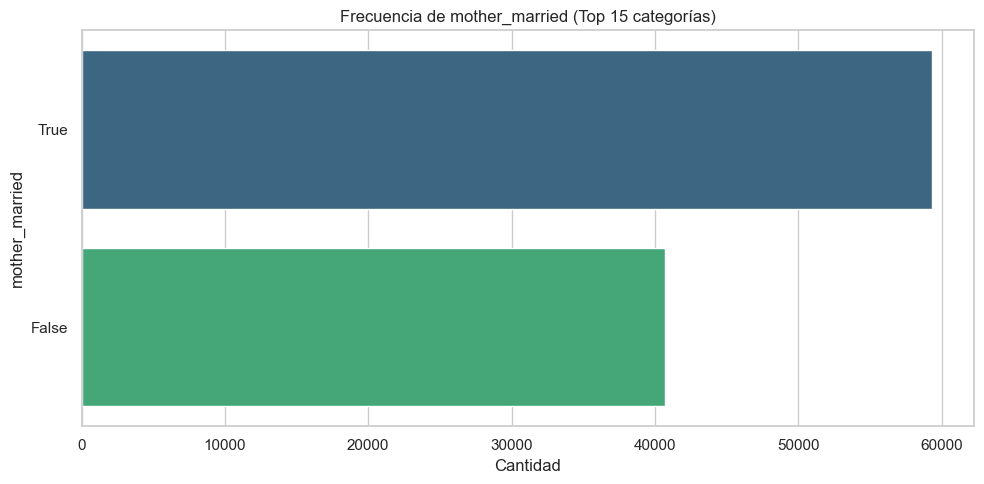

C:\Users\eoar9\AppData\Local\Temp\ipykernel_19996\1353024509.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_muestra, y=col, order=top_cats, palette='viridis')


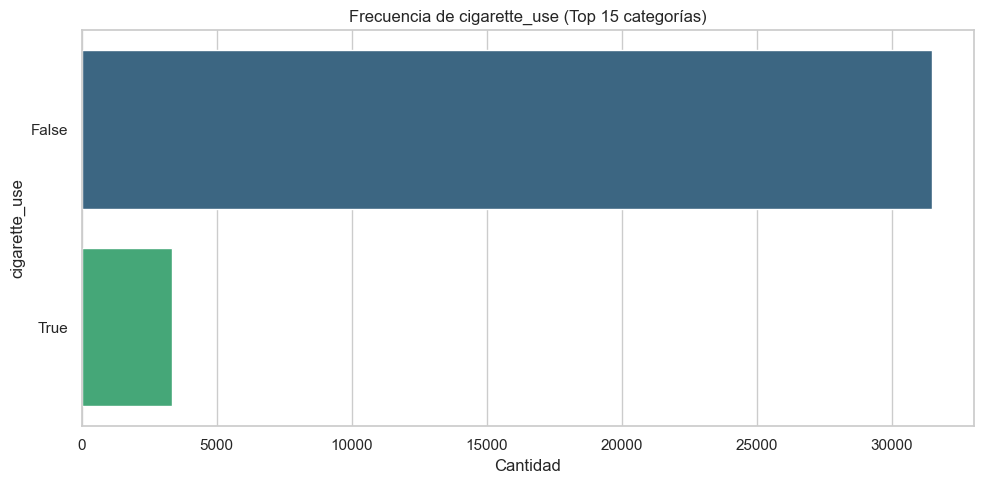

C:\Users\eoar9\AppData\Local\Temp\ipykernel_19996\1353024509.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_muestra, y=col, order=top_cats, palette='viridis')


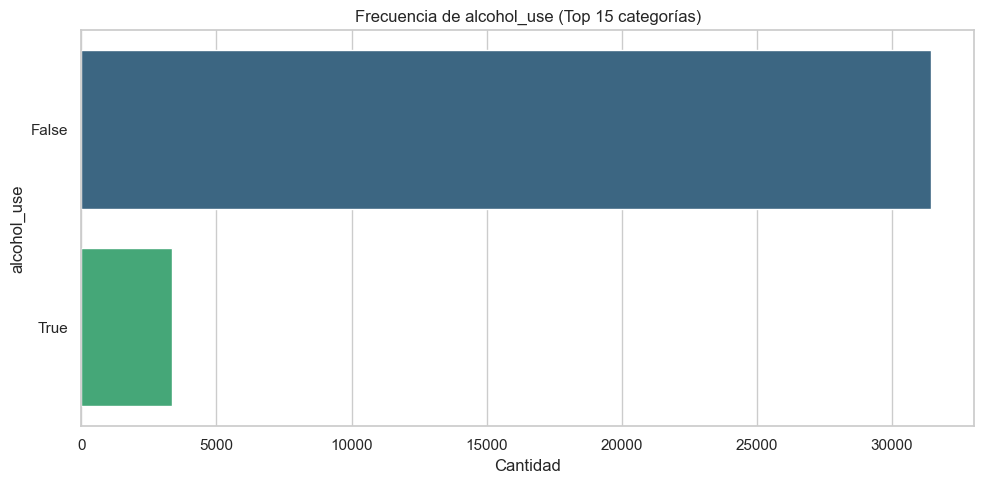

C:\Users\eoar9\AppData\Local\Temp\ipykernel_19996\1353024509.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_muestra, y=col, order=top_cats, palette='viridis')


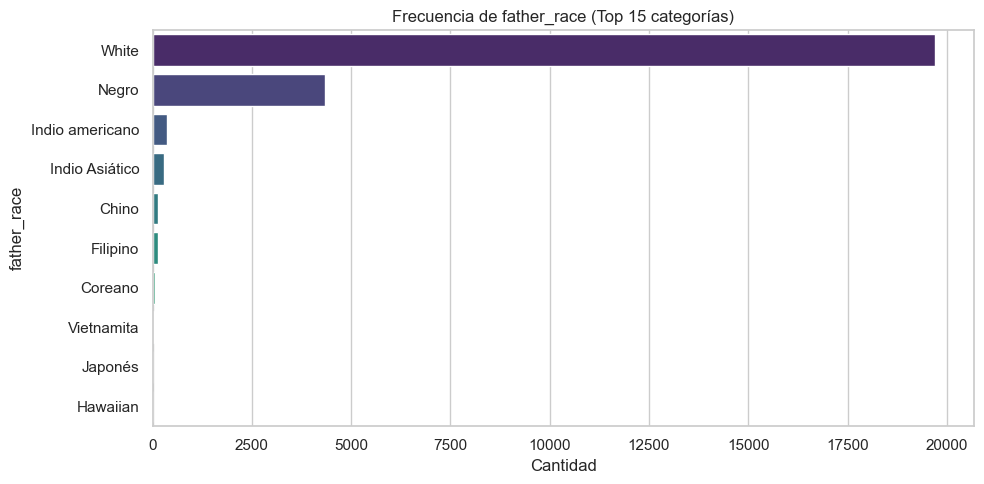

In [13]:
df_analisis = X_train.copy()
df_muestra = df_analisis.sample(min(100_000, len(df_analisis)), random_state=42)

# --- Variables numéricas: distribución + boxplot ---
columnas_num = df_analisis.select_dtypes(include=['number']).columns
print(f"Visualizando {len(columnas_num)} variables numéricas...")

for col in columnas_num:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
    sns.histplot(df_muestra[col].dropna(), bins=50, kde=True, color='steelblue', ax=ax1)
    ax1.set_title(f'Distribución de {col}')
    sns.boxplot(x=df_muestra[col].dropna(), color='lightblue', ax=ax2)
    ax2.set_title(f'Outliers de {col}')
    plt.tight_layout()
    plt.show()

# --- Variables categóricas y booleanas: frecuencias ---
columnas_cat = df_analisis.select_dtypes(include=['object', 'category', 'bool']).columns
print(f"\nVisualizando {len(columnas_cat)} variables categóricas/booleanas...")

for col in columnas_cat:
    plt.figure(figsize=(10, 5))
    top_cats = df_muestra[col].value_counts().index[:15]
    sns.countplot(data=df_muestra, y=col, order=top_cats, palette='viridis')
    plt.title(f'Frecuencia de {col} (Top 15 categorías)')
    plt.xlabel('Cantidad')
    plt.tight_layout()
    plt.show()

---
## Sección 12 — Checkpoint del Dataset

Verificación del estado del dataset antes de pasar al modelado.

In [14]:
print("=" * 60)
print("RESUMEN FINAL DEL DATASET")
print("=" * 60)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Columnas en X: {list(X_train.columns)}")
print(f"\nNulos restantes en X_train:")
nulos_finales = X_train.isnull().sum()
print(nulos_finales[nulos_finales > 0])
print("\nListo para modelado.")

RESUMEN FINAL DEL DATASET
X_train shape: (2978337, 16)
X_test shape:  (1276431, 16)
Columnas en X: ['is_male', 'plurality', 'mother_race', 'mother_age', 'gestation_weeks', 'mother_married', 'cigarette_use', 'cigarettes_per_day', 'alcohol_use', 'weight_gain_pounds', 'father_race', 'father_age', 'cigarette_reported', 'alcohol_reported', 'race_reported', 'weight_gain_reported']

Nulos restantes en X_train:
mother_race           2059922
gestation_weeks          4040
cigarette_use         1937122
cigarettes_per_day    1937122
alcohol_use           1937122
weight_gain_pounds      66486
father_race           2226804
dtype: int64

Listo para modelado.


---
## Sección 13 — Muestra de Desarrollo

### Estrategia de desarrollo iterativo

Con 4.2M registros, entrenar un solo modelo puede tardar horas. La estrategia es:

1. **Desarrollo (1%):** ~29,800 registros → cada modelo tarda segundos → se puede iterar rápido para depurar el código
2. **Producción (100%):** 2.97M registros → se corre de noche una sola vez con el código ya verificado

> **Variable de control:** cambiar `SAMPLE_FRAC = 0.01` a `SAMPLE_FRAC = 1.0` activa automáticamente la configuración de producción en todos los modelos.

> **Regla crítica:** se usa `stratify=y_train` para preservar el 7.88% de positivos en la muestra. Sin esto, con solo 1% podrían quedar casi sin casos de bajo peso.

> **Test siempre completo:** `X_test` nunca se sub-muestrea — `predict()` es rápido y queremos evaluar siempre en las mismas condiciones.

In [15]:
# ── PARÁMETRO PRINCIPAL ──────────────────────────────────────────────────────
SAMPLE_FRAC = 1.0  # 0.01 = desarrollo (1%) | 1.0 = producción (100%)
# ─────────────────────────────────────────────────────────────────────────────

if SAMPLE_FRAC < 1.0:
    X_train_dev, _, y_train_dev, _ = train_test_split(
        X_train, y_train,
        train_size=SAMPLE_FRAC,
        random_state=42,
        stratify=y_train
    )
    print(f"Modo DESARROLLO — usando {SAMPLE_FRAC*100:.0f}% del train")
else:
    X_train_dev = X_train
    y_train_dev = y_train
    print(f"Modo PRODUCCIÓN — usando el train completo")

print(f"Registros de entrenamiento: {len(X_train_dev):,}")
print(f"Positivos (bajo peso):      {y_train_dev.sum():,} ({y_train_dev.mean()*100:.2f}%)")
print(f"Registros de test:          {len(X_test):,}  (siempre completo)")

Modo PRODUCCIÓN — usando el train completo
Registros de entrenamiento: 2,978,337
Positivos (bajo peso):      234,502 (7.87%)
Registros de test:          1,276,431  (siempre completo)


### Conversión Int64 → float64

Las columnas `Int64` (nullable integer de pandas) usan `pandas.NA` para los nulos, que es incompatible con arrays numpy. Se convierten a `float64` que usa `np.nan` — compatible con numpy, sklearn y XGBoost.

In [16]:
int64_cols = X_train.select_dtypes(include='Int64').columns.tolist()
for df_conv in [X_train, X_train_dev, X_test]:
    df_conv[int64_cols] = df_conv[int64_cols].astype('float64')

print(f"Columnas convertidas Int64 -> float64: {int64_cols}")

Columnas convertidas Int64 -> float64: ['plurality', 'mother_age', 'gestation_weeks', 'cigarettes_per_day', 'father_age', 'cigarette_reported', 'alcohol_reported', 'race_reported', 'weight_gain_reported']


### Análisis de Tasa de Bajo Peso por Categoría de Raza

Antes de agrupar categorías pequeñas se verifica si alguna tiene una tasa de bajo peso muy distinta al promedio general (~7.88%). Agrupar una categoría con señal fuerte destruiría información predictiva valiosa.

> **Calculado sobre `X_train` completo** (no la muestra del 1%) porque con pocos registros las tasas son inestables. Por ejemplo, "Vietnamita" con 14 registros en el 1% mostraba una tasa del 14.3% — con los ~1,985 registros reales baja al 6.6%.

In [17]:
print("=" * 60)
print("TASA DE BAJO PESO POR CATEGORÍA DE RAZA (train completo)")
print(f"Referencia general: {y_train.mean()*100:.2f}% de bajo peso")
print("=" * 60)

for col in ['mother_race', 'father_race']:
    if col not in X_train.columns:
        continue

    analisis = pd.DataFrame({
        'categoria': X_train[col].values,
        'bajo_peso': y_train.values
    })

    tasa = (analisis
            .dropna(subset=['categoria'])
            .groupby('categoria')['bajo_peso']
            .agg(n='count', tasa_bajo_peso='mean')
            .assign(
                diferencia_pp=lambda x: (x['tasa_bajo_peso'] - y_train.mean()) * 100,
                pct_sobre_no_nulos=lambda x: x['n'] / x['n'].sum() * 100
            )
            .sort_values('tasa_bajo_peso', ascending=False))

    print(f"\n{col}:")
    print(tasa.round(3).to_string())
    print(f"\n  → Tasa > 2pp sobre promedio: {tasa[tasa['diferencia_pp'] > 2].index.tolist()}")
    print(f"  → Tasa < 2pp bajo promedio:  {tasa[tasa['diferencia_pp'] < -2].index.tolist()}")

TASA DE BAJO PESO POR CATEGORÍA DE RAZA (train completo)
Referencia general: 7.87% de bajo peso

mother_race:
                      n  tasa_bajo_peso  diferencia_pp  pct_sobre_no_nulos
categoria                                                                 
Negro            183669           0.133          5.396              19.998
Indio Asiático     8975           0.097          1.853               0.977
Filipino           5604           0.086          0.745               0.610
Japonés            1008           0.081          0.261               0.110
Indio americano   15806           0.073         -0.541               1.721
Hawaiian            376           0.072         -0.693               0.041
White            694519           0.069         -0.961              75.621
Vietnamita         1327           0.067         -1.167               0.144
Chino              5087           0.053         -2.527               0.554
Coreano            2044           0.043         -3.568           

### Preparación de Variables de Raza (Criterio Dual)

Se resuelven dos problemas antes de pasar al pipeline:

**Problema 1 — NaN como 'Unknown' explícito:**
Imputar con moda (`White`) convertiría 2.9M de NaN en "White" artificialmente. El modelo aprendería *"White → normal"* cuando la realidad es *"sin dato → normal"*. La categoría `Unknown` preserva esta distinción.

**Problema 2 — Categorías pequeñas con criterio dual:**
Un solo umbral de frecuencia no basta. Se conserva una categoría si cumple **cualquiera** de estos criterios:
- Frecuencia ≥ 0.5% sobre no-nulos (volumen suficiente), **O**
- Diferencia ≥ 4pp respecto al promedio (señal predictiva fuerte)

Las categorías no conservadas se dividen en `Other_alto_riesgo` y `Other_bajo_riesgo` para preservar la dirección del riesgo.

In [18]:
def preparar_variables_raza_v2(X_train_dev, X_test, X_train_full, y_train_full,
                                columnas, umbral_freq=0.005, umbral_signal=4.0):
    # Criterio dual para conservar categorias de raza.
    # Stats calculados sobre X_train_full (confiable).
    # Transformacion aplicada sobre X_train_dev y X_test.
    X_dev = X_train_dev.copy()
    X_te  = X_test.copy()
    promedio_global = y_train_full.mean()

    for col in columnas:
        if col not in X_dev.columns:
            continue

        analisis = pd.DataFrame({
            'cat': X_train_full[col].values,
            'target': y_train_full.values
        }).dropna(subset=['cat'])

        stats = analisis.groupby('cat')['target'].agg(['mean', 'count'])
        stats.columns = ['tasa', 'n']
        stats['pct']  = stats['n'] / stats['n'].sum()
        stats['diff'] = (stats['tasa'] - promedio_global) * 100

        conservar = stats[
            (stats['pct'] >= umbral_freq) |
            (stats['diff'].abs() >= umbral_signal)
        ].index.tolist()

        pequenas    = stats[~stats.index.isin(conservar)]
        alto_riesgo = pequenas[pequenas['diff'] >  2].index.tolist()
        bajo_riesgo = pequenas[pequenas['diff'] <= 2].index.tolist()

        print(f"\n{col}:")
        print(f"  Conservadas ({len(conservar)}): {conservar}")
        print(f"  → 'Other_alto_riesgo': {alto_riesgo}")
        print(f"  → 'Other_bajo_riesgo': {bajo_riesgo}")
        print(f"  → 'Unknown':           NaN ({X_dev[col].isna().sum():,} registros en train_dev)")

        def reclasificar(x):
            if pd.isna(x):
                return 'Unknown'
            if x in conservar:
                return x
            if x in stats.index and stats.loc[x, 'diff'] > 2:
                return 'Other_alto_riesgo'
            return 'Other_bajo_riesgo'

        X_dev[col] = X_dev[col].apply(reclasificar)
        X_te[col]  = X_te[col].apply(reclasificar)
        print(f"  Distribución final train_dev: {X_dev[col].value_counts().to_dict()}")

    return X_dev, X_te


X_train_dev, X_test = preparar_variables_raza_v2(
    X_train_dev, X_test,
    X_train_full=X_train,
    y_train_full=y_train,
    columnas=['mother_race', 'father_race'],
    umbral_freq=0.005,
    umbral_signal=4.0
)


mother_race:
  Conservadas (6): ['Chino', 'Filipino', 'Indio Asiático', 'Indio americano', 'Negro', 'White']
  → 'Other_alto_riesgo': []
  → 'Other_bajo_riesgo': ['Coreano', 'Hawaiian', 'Japonés', 'Vietnamita']
  → 'Unknown':           NaN (2,059,922 registros en train_dev)
  Distribución final train_dev: {'Unknown': 2059922, 'White': 694519, 'Negro': 183669, 'Indio americano': 15806, 'Indio Asiático': 8975, 'Filipino': 5604, 'Chino': 5087, 'Other_bajo_riesgo': 4755}

father_race:
  Conservadas (6): ['Chino', 'Filipino', 'Indio Asiático', 'Indio americano', 'Negro', 'White']
  → 'Other_alto_riesgo': []
  → 'Other_bajo_riesgo': ['Coreano', 'Hawaiian', 'Japonés', 'Vietnamita']
  → 'Unknown':           NaN (2,226,804 registros en train_dev)
  Distribución final train_dev: {'Unknown': 2226804, 'White': 590286, 'Negro': 129401, 'Indio americano': 10800, 'Indio Asiático': 8943, 'Chino': 4374, 'Filipino': 3885, 'Other_bajo_riesgo': 3844}


---
## Sección 14 — Pipeline de Preprocesamiento Compartido

Un **pipeline** en machine learning es una cadena de pasos de transformación encadenados que se trata como una sola unidad. El beneficio clave es evitar **data leakage**: el pipeline aprende (fit) los parámetros de transformación *solo sobre train* y los aplica (transform) sobre test sin re-aprender nada.

### ColumnTransformer — transformaciones por tipo de columna

| Tipo | Columnas | Transformaciones |
|------|----------|-----------------|
| Numéricas | 10 columnas | Mediana (NaN) + StandardScaler |
| Categóricas | `mother_race`, `father_race` | OneHotEncoder (sin imputer — NaN ya son 'Unknown') |
| Booleanas | `is_male`, `mother_married`, `cigarette_use`, `alcohol_use` | Moda (NaN) |

> **Para XGBoost:** se usa un preprocessor especial con `'passthrough'` en lugar de `StandardScaler` para las numéricas. XGBoost es invariante a la escala (árboles) y maneja NaN nativamente.

In [19]:
# --- Definición de columnas por tipo ---
numeric_features = [
    'gestation_weeks', 'mother_age', 'cigarettes_per_day',
    'father_age', 'plurality', 'weight_gain_pounds',
    'cigarette_reported', 'alcohol_reported', 'race_reported',
    'weight_gain_reported'
]
categorical_features = ['mother_race', 'father_race']
bool_features = ['is_male', 'mother_married', 'cigarette_use', 'alcohol_use']

# Filtrar solo columnas existentes
numeric_features     = [c for c in numeric_features     if c in X_train_dev.columns]
categorical_features = [c for c in categorical_features if c in X_train_dev.columns]
bool_features        = [c for c in bool_features        if c in X_train_dev.columns]

# --- Transformers ---
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
bool_transformer = SimpleImputer(strategy='most_frequent')

# --- Preprocessor estándar (LR, SVM, Bagging, RF) ---
preprocessor = ColumnTransformer(transformers=[
    ('num',  numeric_transformer,    numeric_features),
    ('cat',  categorical_transformer, categorical_features),
    ('bool', bool_transformer,        bool_features)
])

# --- Preprocessor para XGBoost (passthrough en numéricas) ---
preprocessor_xgb = ColumnTransformer(transformers=[
    ('num',  'passthrough',          numeric_features),
    ('cat',  categorical_transformer, categorical_features),
    ('bool', bool_transformer,        bool_features)
])

print("Pipeline de preprocesamiento definido.")
print(f"  Numéricas ({len(numeric_features)}):    {numeric_features}")
print(f"  Categóricas ({len(categorical_features)}):  {categorical_features}")
print(f"  Booleanas ({len(bool_features)}):    {bool_features}")

Pipeline de preprocesamiento definido.
  Numéricas (10):    ['gestation_weeks', 'mother_age', 'cigarettes_per_day', 'father_age', 'plurality', 'weight_gain_pounds', 'cigarette_reported', 'alcohol_reported', 'race_reported', 'weight_gain_reported']
  Categóricas (2):  ['mother_race', 'father_race']
  Booleanas (4):    ['is_male', 'mother_married', 'cigarette_use', 'alcohol_use']


---
## Sección 15 — Funciones de Evaluación Compartidas

Se definen dos funciones reutilizables:

- **`evaluar_modelo()`:** entrena el pipeline, calcula AUC y Recall, y guarda los resultados en el diccionario `resultados` para la comparativa final.
- **`graficar_roc_comparativa()`:** grafica todas las curvas ROC acumuladas en una sola figura.

### ¿Por qué umbral ajustable?

Por defecto sklearn clasifica como positivo cuando la probabilidad ≥ 0.5. Pero algunos modelos (especialmente SVM con calibración Platt scaling) producen probabilidades más conservadoras — con umbral 0.5 dan Recall muy bajo aunque su AUC sea bueno. El umbral ajustable permite comparar modelos en condiciones equivalentes.

> **El AUC no cambia con el umbral** — se calcula sobre todas las probabilidades y es la métrica correcta para comparar modelos. El Recall y Precision sí cambian.

In [20]:
import gc

# Liberar df_raw (~2-3GB) que ya no se necesita para el modelado
# Con 16GB RAM, cada GB cuenta al correr Bagging/RF sobre 3M registros
try:
    del df_raw
except NameError:
    pass
gc.collect()
print("Memoria liberada. Listo para modelado.")

Memoria liberada. Listo para modelado.


In [21]:
resultados = {}

def evaluar_modelo(nombre, pipeline, X_tr, y_tr, X_te, y_te, umbral=0.5):
    print(f"\n{'='*55}")
    print(f"  Entrenando: {nombre}")
    print(f"{'='*55}")

    pipeline.fit(X_tr, y_tr)

    y_prob = pipeline.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= umbral).astype(int)

    auc    = roc_auc_score(y_te, y_prob)
    recall = recall_score(y_te, y_pred)
    fpr, tpr, _ = roc_curve(y_te, y_prob)

    print(f"\nAUC:    {auc:.4f}  (umbral usado: {umbral})")
    print(f"Recall: {recall:.4f}  ← % bebés bajo peso correctamente detectados")
    print("\nReporte detallado:")
    print(classification_report(y_te, y_pred, target_names=['Normal', 'Bajo peso']))

    resultados[nombre] = {
        'auc': auc, 'recall': recall,
        'fpr': fpr, 'tpr': tpr, 'umbral': umbral
    }
    return auc, recall


def graficar_roc_comparativa():
    plt.figure(figsize=(9, 7))
    colores = ['steelblue', 'coral', 'teal', 'green',
               'goldenrod', 'purple', 'crimson', 'darkorange']

    for (nombre, vals), color in zip(resultados.items(), colores):
        plt.plot(vals['fpr'], vals['tpr'], lw=2, color=color,
                 label=f"{nombre}  (AUC={vals['auc']:.4f}  Recall={vals['recall']:.4f})")

    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
    plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
    plt.ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=12)
    plt.title('Curva ROC — Comparativa de Modelos', fontsize=14)
    plt.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.savefig('roc_comparativa_final.png', dpi=150)
    plt.show()
    print("Gráfica guardada como 'roc_comparativa_final.png'")

---
## Modelo Ingenuo — Regresión Logística sin Optimización (Baseline)

Punto de referencia mínimo: Regresión Logística sin búsqueda de hiperparámetros. Permite cuantificar el valor real del feature engineering y la optimización al comparar contra los modelos más elaborados.

> **¿Por qué mantener `class_weight='balanced'`?** Sin él el modelo predice todo como "normal" (92% de los casos) y Recall = 0% — eso no es un baseline útil, es un modelo roto. Lo que lo hace "ingenuo" es la ausencia de tuning, no la ausencia de corrección del desbalance.


  Entrenando: LR Ingenuo (baseline)


c:\Users\eoar9\Documents\Analitica II\Proyecto Final\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



AUC:    0.8858  (umbral usado: 0.5)
Recall: 0.7641  ← % bebés bajo peso correctamente detectados

Reporte detallado:
              precision    recall  f1-score   support

      Normal       0.98      0.88      0.93   1175930
   Bajo peso       0.36      0.76      0.49    100501

    accuracy                           0.87   1276431
   macro avg       0.67      0.82      0.71   1276431
weighted avg       0.93      0.87      0.89   1276431



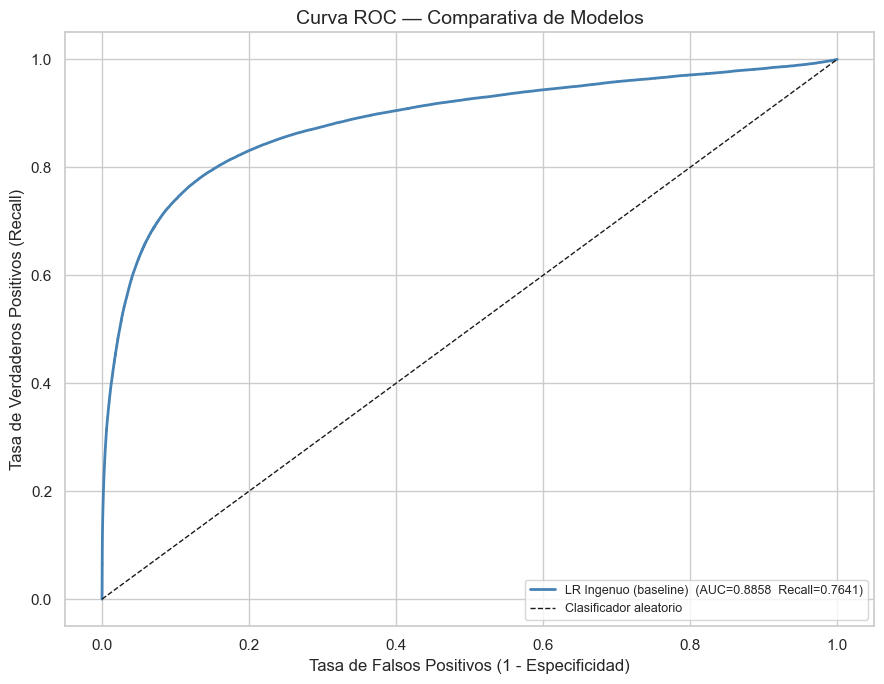

Gráfica guardada como 'roc_comparativa_final.png'


In [22]:
# max_iter: 500 en desarrollo / 2000 en producción (saga puede no converger con 3M filas)
max_iter_lr = 500 if SAMPLE_FRAC < 1.0 else 2000

pipeline_lr_ingenuo = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        solver='saga',
        max_iter=max_iter_lr,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

evaluar_modelo(
    nombre='LR Ingenuo (baseline)',
    pipeline=pipeline_lr_ingenuo,
    X_tr=X_train_dev, y_tr=y_train_dev,
    X_te=X_test,      y_te=y_test,
    umbral=0.5
)
graficar_roc_comparativa()

---
## Modelo 1 — Regresión Logística con Regularización (GridSearchCV)

Se busca la mejor combinación de regularización y fuerza mediante `GridSearchCV`.

### ¿Qué es la regularización?

| Tipo | Parámetro | Efecto |
|------|-----------|--------|
| **Ridge (L2)** | `penalty='l2'` | Reduce todos los coeficientes proporcionalmente. Ninguno llega a cero — todas las features se mantienen. |
| **Lasso (L1)** | `penalty='l1'` | Fuerza algunos coeficientes exactamente a cero → selección automática de features incorporada. |
| **ElasticNet** | `penalty='elasticnet'` | Combinación de L1 y L2. Más flexible, requiere `l1_ratio`. |

**C** es el inverso de la fuerza de regularización:
- `C = 0.01` → regularización fuerte → modelo más simple
- `C = 100` → regularización débil → modelo más complejo

### ¿Por qué `scoring='roc_auc'`?

Con clases desbalanceadas (92%/8%) **nunca se usa accuracy** como criterio de selección — favorecería predecir todo como "normal" (92% accuracy sin aprender nada útil). El AUC mide la capacidad real de discriminación entre clases.

### Estrategia de memoria: GridSearchCV sobre el 10% del train

Con 2.97M registros y `cv=3`, cada fold tiene ~990k registros. Con `n_jobs>1`, joblib copia el DataFrame completo por proceso → `MemoryError` en equipos con 16GB RAM.

Solución en dos pasos:
1. **Encontrar los hiperparámetros** sobre el 10% del train (297k registros) — estadísticamente suficiente para que el grid sea estable
2. **Reentrenar el modelo final** con el train completo usando los mejores hiperparámetros encontrados

Esta es práctica estándar en la industria cuando el grid search completo es inviable por memoria o tiempo.

Muestra para GridSearchCV: 297,833 registros (10% del train)

mother_race:
  Conservadas (6): ['Chino', 'Filipino', 'Indio Asiático', 'Indio americano', 'Negro', 'White']
  → 'Other_alto_riesgo': []
  → 'Other_bajo_riesgo': ['Coreano', 'Hawaiian', 'Japonés', 'Vietnamita']
  → 'Unknown':           NaN (206,250 registros en train_dev)
  Distribución final train_dev: {'Unknown': 206250, 'White': 69380, 'Negro': 18114, 'Indio americano': 1658, 'Indio Asiático': 896, 'Filipino': 568, 'Other_bajo_riesgo': 492, 'Chino': 475}

father_race:
  Conservadas (6): ['Chino', 'Filipino', 'Indio Asiático', 'Indio americano', 'Negro', 'White']
  → 'Other_alto_riesgo': []
  → 'Other_bajo_riesgo': ['Coreano', 'Hawaiian', 'Japonés', 'Vietnamita']
  → 'Unknown':           NaN (222,906 registros en train_dev)
  Distribución final train_dev: {'Unknown': 222906, 'White': 58899, 'Negro': 12819, 'Indio americano': 1127, 'Indio Asiático': 900, 'Chino': 412, 'Other_bajo_riesgo': 391, 'Filipino': 379}
GridSearchCV:

c:\Users\eoar9\Documents\Analitica II\Proyecto Final\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\eoar9\Documents\Analitica II\Proyecto Final\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\eoar9\Documents\Analitica II\Proyecto Final\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l


Mejor combinacion (sobre 10% del train):
  penalty  : l2
  C        : 0.01
  AUC (CV) : 0.8882

Reentrenando modelo final sobre 2,978,337 registros...

  Entrenando: LR Regularizada (M1)


c:\Users\eoar9\Documents\Analitica II\Proyecto Final\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\eoar9\Documents\Analitica II\Proyecto Final\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



AUC:    0.8858  (umbral usado: 0.5)
Recall: 0.7640  ← % bebés bajo peso correctamente detectados

Reporte detallado:
              precision    recall  f1-score   support

      Normal       0.98      0.88      0.93   1175930
   Bajo peso       0.36      0.76      0.49    100501

    accuracy                           0.87   1276431
   macro avg       0.67      0.82      0.71   1276431
weighted avg       0.93      0.87      0.89   1276431



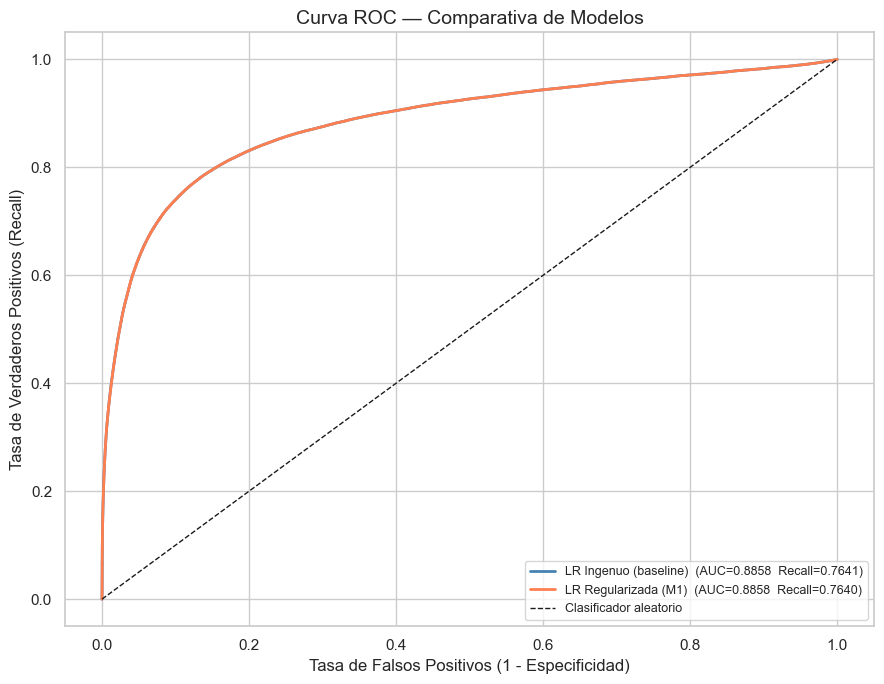

Gráfica guardada como 'roc_comparativa_final.png'


In [23]:
param_grid = [
    {"classifier__penalty": ["l2"],
     "classifier__C":       [0.01, 0.1, 1, 10, 100]},
    {"classifier__penalty": ["l1"],
     "classifier__C":       [0.01, 0.1, 1, 10, 100]},
    {"classifier__penalty": ["elasticnet"],
     "classifier__C":       [0.01, 0.1, 1, 10, 100],
     "classifier__l1_ratio": [0.25, 0.5, 0.75]}
]

pipeline_lr_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="saga",
        max_iter=max_iter_lr,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# Con 2.97M registros y cv=3, cada fold tiene ~990k registros.
# n_jobs>1 copia el DataFrame por proceso -> MemoryError con 16GB RAM.
# Solucion: encontrar hiperparametros en 10% y reentrenar con train completo.
GRID_FRAC = 0.10
X_grid, _, y_grid, _ = train_test_split(
    X_train, y_train,
    train_size=GRID_FRAC,
    random_state=42,
    stratify=y_train
)
print(f"Muestra para GridSearchCV: {len(X_grid):,} registros ({GRID_FRAC*100:.0f}% del train)")

X_grid, _ = preparar_variables_raza_v2(
    X_grid, X_test,
    X_train_full=X_train,
    y_train_full=y_train,
    columnas=["mother_race", "father_race"],
    umbral_freq=0.005,
    umbral_signal=4.0
)
int64_cols_grid = X_grid.select_dtypes(include="Int64").columns.tolist()
if int64_cols_grid:
    X_grid[int64_cols_grid] = X_grid[int64_cols_grid].astype("float64")

n_combinaciones = sum(
    len(p["classifier__C"]) * len(p.get("classifier__l1_ratio", [1]))
    for p in param_grid
)
print(f"GridSearchCV: cv=3, {n_combinaciones} combinaciones ({n_combinaciones*3} modelos totales)")

grid_lr = GridSearchCV(
    estimator=pipeline_lr_reg,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=1,
    verbose=1
)
grid_lr.fit(X_grid, y_grid)

print(f"\nMejor combinacion (sobre {GRID_FRAC*100:.0f}% del train):")
print(f"  penalty  : {grid_lr.best_params_['classifier__penalty']}")
print(f"  C        : {grid_lr.best_params_['classifier__C']}")
if "classifier__l1_ratio" in grid_lr.best_params_:
    print(f"  l1_ratio : {grid_lr.best_params_['classifier__l1_ratio']}")
print(f"  AUC (CV) : {grid_lr.best_score_:.4f}")

print(f"\nReentrenando modelo final sobre {len(X_train_dev):,} registros...")
evaluar_modelo(
    nombre="LR Regularizada (M1)",
    pipeline=grid_lr.best_estimator_,
    X_tr=X_train_dev, y_tr=y_train_dev,
    X_te=X_test,      y_te=y_test,
    umbral=0.5
)
graficar_roc_comparativa()

---
## Modelo 2 — SVM Lineal

### ¿Por qué no SVC con kernel RBF?

SVC con kernel construye una matriz de n×n durante el entrenamiento:
- Con 29k registros (1% muestra): ~841M entradas (~6.7 GB RAM)
- Con 3M registros (producción): físicamente imposible

`LinearSVC` escala linealmente O(n × features) → viable con millones de filas.

### ¿Por qué `CalibratedClassifierCV`?

`LinearSVC` no tiene `predict_proba()` — necesario para construir la curva ROC. `CalibratedClassifierCV` agrega calibración de probabilidades mediante Platt scaling (método `sigmoid`) con 3 folds internos.

### Umbral = 0.3

La calibración Platt scaling no preserva perfectamente el efecto de `class_weight='balanced'`. El SVM tiende a ser conservador → Recall bajo con umbral 0.5. Bajarlo a 0.3 permite una comparativa más justa. El AUC no cambia con el umbral.


  Entrenando: SVM Lineal

AUC:    0.8857  (umbral usado: 0.3)
Recall: 0.5073  ← % bebés bajo peso correctamente detectados

Reporte detallado:
              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97   1175930
   Bajo peso       0.64      0.51      0.56    100501

    accuracy                           0.94   1276431
   macro avg       0.80      0.74      0.77   1276431
weighted avg       0.93      0.94      0.94   1276431



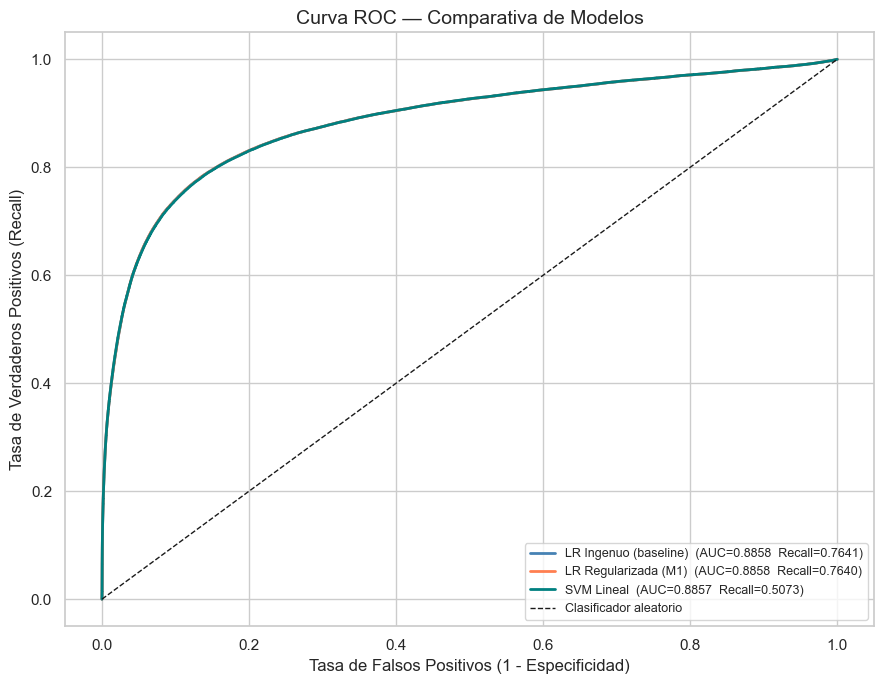

Gráfica guardada como 'roc_comparativa_final.png'


In [24]:
# max_iter: 2000 dev / 5000 prod (LinearSVC tarda más en converger que LR)
max_iter_svm = 2000 if SAMPLE_FRAC < 1.0 else 5000

svc_base = LinearSVC(
    class_weight='balanced',
    max_iter=max_iter_svm,
    random_state=42
)

pipeline_svm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', CalibratedClassifierCV(
        estimator=svc_base,
        cv=3,
        method='sigmoid'
    ))
])

evaluar_modelo(
    nombre='SVM Lineal',
    pipeline=pipeline_svm,
    X_tr=X_train_dev, y_tr=y_train_dev,
    X_te=X_test,      y_te=y_test,
    umbral=0.3
)
graficar_roc_comparativa()

---
## Modelo 3 — Bagging (Bootstrap Aggregating)

**Idea central:** entrenar múltiples árboles de decisión sobre muestras bootstrap (con reemplazo) del train y promediar sus predicciones. Reduce la varianza sin aumentar el sesgo.

**¿Por qué funciona?** Un árbol de decisión individual tiene alta varianza — pequeños cambios en los datos producen árboles muy distintos. Al promediar 200 árboles entrenados en muestras ligeramente distintas, la varianza se cancela mientras el sesgo se mantiene bajo.

### Hiperparámetros escalados con SAMPLE_FRAC

| Parámetro | Desarrollo (1%) | Producción (100%) |
|-----------|-----------------|-------------------|
| `n_estimators` | 50 | 200 |
| `max_samples` | 0.3 | 0.7 (~2.1M registros/árbol) |
| `max_depth` | 15 | None |

> **`max_depth` condicional:** con pocos datos (1%) los árboles sin límite memorizan las ~8,700 submuestras. Con 3M registros hay suficiente masa estadística para que `max_depth=None` funcione correctamente.

Bagging — configuracion activa:
  n_estimators: 100  (50 dev / 100 prod)
  max_samples : 0.7
  max_depth   : 20 (produccion)

  Entrenando: Bagging

AUC:    0.8788  (umbral usado: 0.5)
Recall: 0.6910  ← % bebés bajo peso correctamente detectados

Reporte detallado:
              precision    recall  f1-score   support

      Normal       0.97      0.92      0.94   1175930
   Bajo peso       0.41      0.69      0.52    100501

    accuracy                           0.90   1276431
   macro avg       0.69      0.80      0.73   1276431
weighted avg       0.93      0.90      0.91   1276431



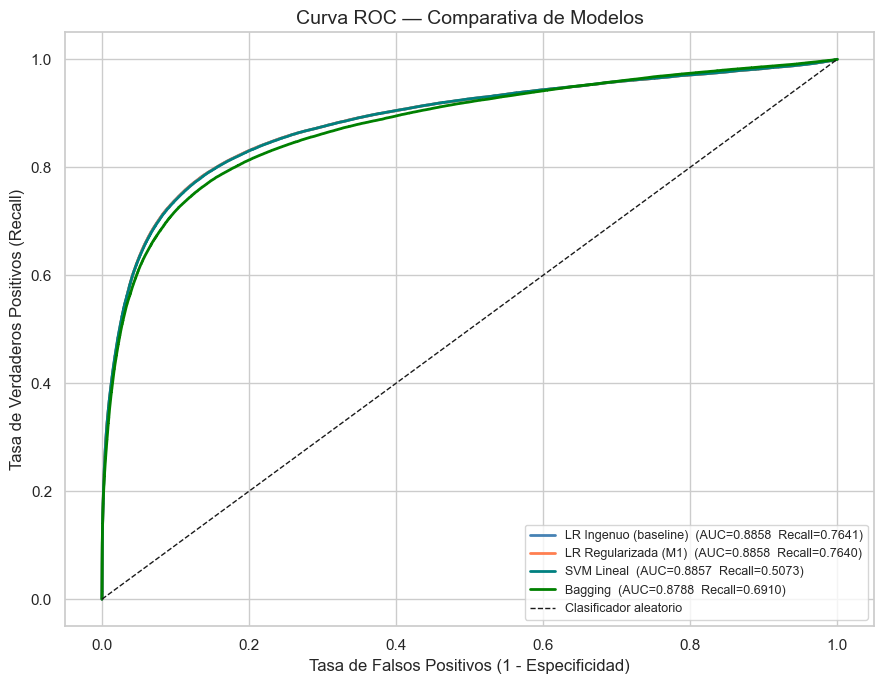

Gráfica guardada como 'roc_comparativa_final.png'


In [25]:
n_estimators_bag = 50   if SAMPLE_FRAC < 1.0 else 100
max_samples_bag  = 0.3  if SAMPLE_FRAC < 1.0 else 0.7
max_depth_bag    = 15   if SAMPLE_FRAC < 1.0 else 20

print(f"Bagging — configuracion activa:")
print(f"  n_estimators: {n_estimators_bag}  (50 dev / 100 prod)")
print(f"  max_samples : {max_samples_bag}")
print(f"  max_depth   : {max_depth_bag} ({'desarrollo' if SAMPLE_FRAC < 1.0 else 'produccion'})")

base_tree = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=max_depth_bag,
    random_state=42
)

pipeline_bagging = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', BaggingClassifier(
        estimator=base_tree,
        n_estimators=n_estimators_bag,
        max_samples=max_samples_bag,
        max_features=1.0,
        bootstrap=True,
        random_state=42,
        n_jobs=1        # Secuencial: evita OOM en 16GB RAM
    ))
])

evaluar_modelo(
    nombre='Bagging',
    pipeline=pipeline_bagging,
    X_tr=X_train_dev, y_tr=y_train_dev,
    X_te=X_test,      y_te=y_test,
    umbral=0.5
)
graficar_roc_comparativa()

---
## Modelo 4 — Random Forest

**Diferencia clave respecto al Bagging:** además del bootstrap de registros, en cada split de cada árbol solo considera un subconjunto aleatorio de features (`max_features='sqrt'`). Esto **descorrela los árboles entre sí** — el promedio reduce más la varianza que con Bagging donde los árboles pueden ser similares.

> **`class_weight='balanced_subsample'`:** recalcula los pesos en cada muestra bootstrap en lugar de sobre el dataset completo. Es más apropiado que `'balanced'` para RF porque cada árbol ve una muestra distinta.

Random Forest — configuracion activa:
  n_estimators: 100  (50 dev / 100 prod)
  max_depth   : 20 (produccion)

  Entrenando: Random Forest

AUC:    0.8893  (umbral usado: 0.5)
Recall: 0.7389  ← % bebés bajo peso correctamente detectados

Reporte detallado:
              precision    recall  f1-score   support

      Normal       0.98      0.90      0.93   1175930
   Bajo peso       0.38      0.74      0.50    100501

    accuracy                           0.88   1276431
   macro avg       0.68      0.82      0.72   1276431
weighted avg       0.93      0.88      0.90   1276431



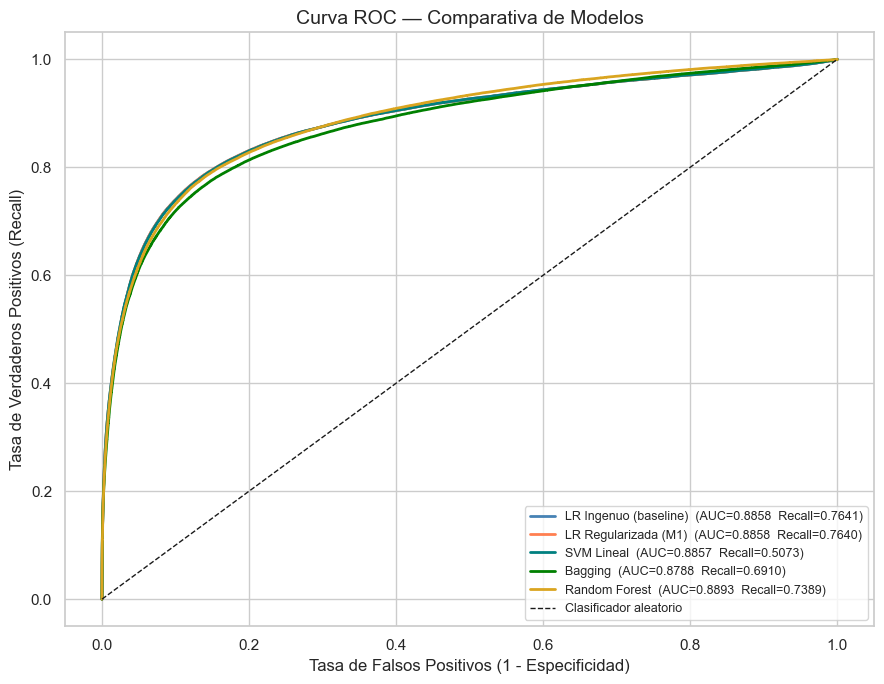

Gráfica guardada como 'roc_comparativa_final.png'


In [26]:
n_estimators_rf = 50   if SAMPLE_FRAC < 1.0 else 100
max_depth_rf    = 15   if SAMPLE_FRAC < 1.0 else 20

print(f"Random Forest — configuracion activa:")
print(f"  n_estimators: {n_estimators_rf}  (50 dev / 100 prod)")
print(f"  max_depth   : {max_depth_rf} ({'desarrollo' if SAMPLE_FRAC < 1.0 else 'produccion'})")

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=n_estimators_rf,
        max_depth=max_depth_rf,
        max_features='sqrt',
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=1        # Secuencial: evita OOM en 16GB RAM
    ))
])

evaluar_modelo(
    nombre='Random Forest',
    pipeline=pipeline_rf,
    X_tr=X_train_dev, y_tr=y_train_dev,
    X_te=X_test,      y_te=y_test,
    umbral=0.5
)
graficar_roc_comparativa()

---
## Modelo 5 — XGBoost

**Gradient Boosting** — a diferencia de Bagging y RF que entrenan árboles en paralelo e independientes, XGBoost los entrena en **secuencia**: cada árbol corrige los errores del anterior minimizando el gradiente del error. Resultado: menor sesgo que RF/Bagging.

### Parámetros clave

- **`scale_pos_weight = 11.7`:** equivalente a `class_weight='balanced'` para XGBoost. Se calcula como `n_negativos / n_positivos = 92.13 / 7.87 ≈ 11.7`. Le dice al modelo que cada positivo (bajo peso) vale 11.7 veces más.
- **`subsample=0.8`:** cada árbol usa 80% de los registros → reduce overfitting.
- **`colsample_bytree=0.8`:** cada árbol usa 80% de las features → similar al RF.

### Preprocessor especial

XGBoost **no necesita escalado** (invariante a escala) y **maneja NaN nativamente** (aprende la dirección óptima para valores faltantes). Por eso se usa `'passthrough'` en lugar de `StandardScaler` para las numéricas.

XGBoost scale_pos_weight: 11.70
XGBoost — configuración activa:
  n_estimators: 500
  max_depth   : 8 (producción)

  Entrenando: XGBoost

AUC:    0.8958  (umbral usado: 0.5)
Recall: 0.7804  ← % bebés bajo peso correctamente detectados

Reporte detallado:
              precision    recall  f1-score   support

      Normal       0.98      0.87      0.92   1175930
   Bajo peso       0.35      0.78      0.48    100501

    accuracy                           0.87   1276431
   macro avg       0.66      0.83      0.70   1276431
weighted avg       0.93      0.87      0.89   1276431



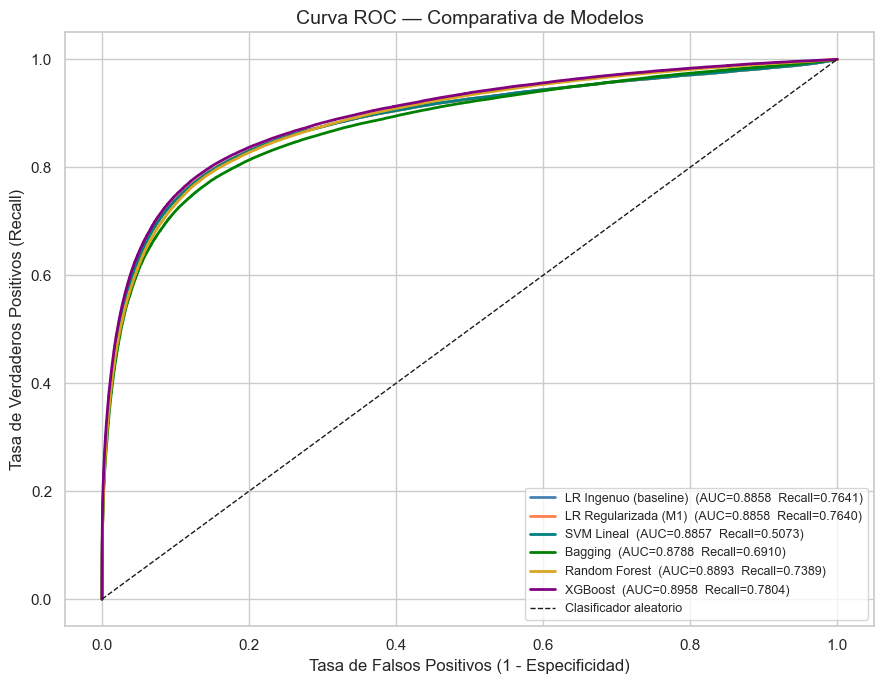

Gráfica guardada como 'roc_comparativa_final.png'


In [27]:
scale_pos_weight = (y_train == False).sum() / (y_train == True).sum()
print(f"XGBoost scale_pos_weight: {scale_pos_weight:.2f}")

n_estimators_xgb = 100 if SAMPLE_FRAC < 1.0 else 500
max_depth_xgb    = 6   if SAMPLE_FRAC < 1.0 else 8

print(f"XGBoost — configuración activa:")
print(f"  n_estimators: {n_estimators_xgb}")
print(f"  max_depth   : {max_depth_xgb} ({'desarrollo' if SAMPLE_FRAC < 1.0 else 'producción'})")

pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor_xgb),
    ('classifier', XGBClassifier(
        n_estimators=n_estimators_xgb,
        max_depth=max_depth_xgb,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric='auc',
        verbosity=0
    ))
])

evaluar_modelo(
    nombre='XGBoost',
    pipeline=pipeline_xgb,
    X_tr=X_train_dev, y_tr=y_train_dev,
    X_te=X_test,      y_te=y_test,
    umbral=0.5
)
graficar_roc_comparativa()

### TUNING XGBOOST — Búsqueda secuencial
* Se tunea un parámetro a la vez para evitar el grid completo (108 fits × 3 min).
* Orden: primero n_estimators+learning_rate (mayor impacto), luego los demás.
* Cada ronda tarda ~15-20 minutos → resultados rápidos y accionables.

Muestra para grid XGBoost: 595,667 registros
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Mejor n_estimators : 500
Mejor learning_rate: 0.05
AUC (CV)           : 0.8916
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Mejor max_depth        : 6
Mejor min_child_weight : 10
AUC (CV)               : 0.8976

Entrenando XGBoost optimizado sobre train completo...
  n_estimators    : 500
  learning_rate   : 0.05
  max_depth       : 6
  min_child_weight: 10

  Entrenando: XGBoost Optimizado

AUC:    0.8986  (umbral usado: 0.5)
Recall: 0.7866  ← % bebés bajo peso correctamente detectados

Reporte detallado:
              precision    recall  f1-score   support

      Normal       0.98      0.87      0.92   1175930
   Bajo peso       0.34      0.79      0.48    100501

    accuracy                           0.86   1276431
   macro avg       0.66      0.83      0.70   1276431
weighted avg       0.93      0.86      0.89   1276431



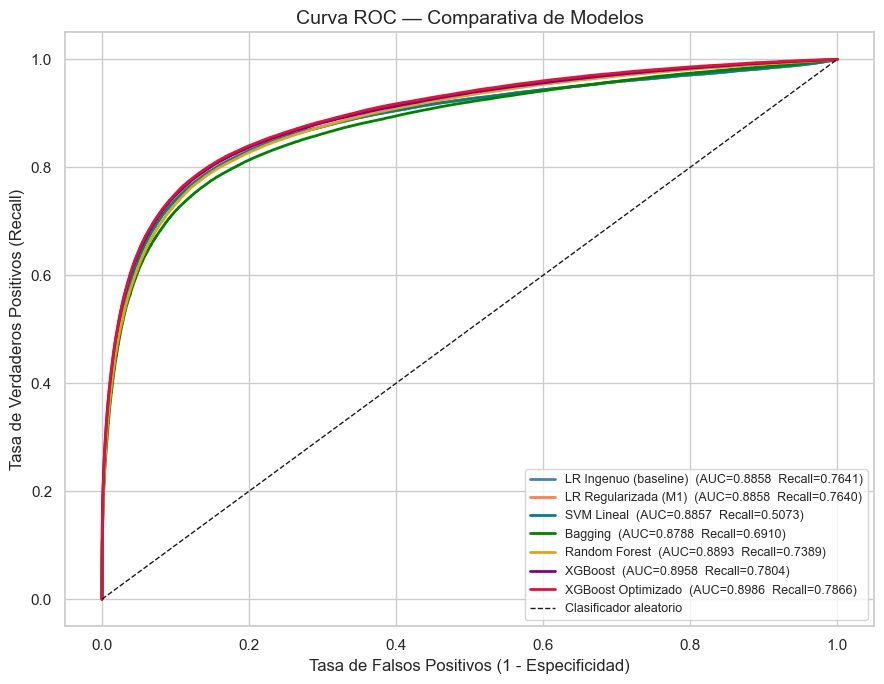

Gráfica guardada como 'roc_comparativa_final.png'


In [28]:
from sklearn.model_selection import GridSearchCV

# --- Ronda 1: n_estimators y learning_rate ---
# Son los más interdependientes — siempre se tunean juntos.
# learning_rate bajo + más árboles suele ganar, pero tiene límite de retorno.
param_grid_xgb_r1 = {
    'classifier__n_estimators':  [500, 1000, 1500],
    'classifier__learning_rate': [0.05, 0.1],
}
# 3 × 2 = 6 combinaciones × cv=3 = 18 fits → ~15-20 min

pipeline_xgb_tune = Pipeline(steps=[
    ('preprocessor', preprocessor_xgb),
    ('classifier', XGBClassifier(
        max_depth=8,
        scale_pos_weight=scale_pos_weight,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric='auc',
        verbosity=0
    ))
])

grid_xgb_r1 = GridSearchCV(
    estimator=pipeline_xgb_tune,
    param_grid=param_grid_xgb_r1,
    scoring='roc_auc',
    cv=3,
    n_jobs=1,      # Secuencial — evita MemoryError en Windows
    verbose=1
)

# Usar 20% del train para el grid — suficiente estadísticamente y más rápido
X_grid_xgb, _, y_grid_xgb, _ = train_test_split(
    X_train_dev, y_train_dev,
    train_size=0.2,
    random_state=42,
    stratify=y_train_dev
)
print(f"Muestra para grid XGBoost: {len(X_grid_xgb):,} registros")

grid_xgb_r1.fit(X_grid_xgb, y_grid_xgb)

print(f"\nMejor n_estimators : {grid_xgb_r1.best_params_['classifier__n_estimators']}")
print(f"Mejor learning_rate: {grid_xgb_r1.best_params_['classifier__learning_rate']}")
print(f"AUC (CV)           : {grid_xgb_r1.best_score_:.4f}")

# --- Ronda 2: max_depth y min_child_weight (con los mejores de R1) ---
best_n_est = grid_xgb_r1.best_params_['classifier__n_estimators']
best_lr    = grid_xgb_r1.best_params_['classifier__learning_rate']

param_grid_xgb_r2 = {
    'classifier__max_depth':        [6, 8, 10],
    'classifier__min_child_weight': [1, 5, 10],
}
# 3 × 3 = 9 combinaciones × cv=3 = 27 fits → ~15-20 min

pipeline_xgb_tune2 = Pipeline(steps=[
    ('preprocessor', preprocessor_xgb),
    ('classifier', XGBClassifier(
        n_estimators=best_n_est,
        learning_rate=best_lr,
        scale_pos_weight=scale_pos_weight,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric='auc',
        verbosity=0
    ))
])

grid_xgb_r2 = GridSearchCV(
    estimator=pipeline_xgb_tune2,
    param_grid=param_grid_xgb_r2,
    scoring='roc_auc',
    cv=3,
    n_jobs=1,
    verbose=1
)

grid_xgb_r2.fit(X_grid_xgb, y_grid_xgb)

print(f"\nMejor max_depth        : {grid_xgb_r2.best_params_['classifier__max_depth']}")
print(f"Mejor min_child_weight : {grid_xgb_r2.best_params_['classifier__min_child_weight']}")
print(f"AUC (CV)               : {grid_xgb_r2.best_score_:.4f}")

# --- Modelo XGBoost final con mejores hiperparámetros ---
best_depth = grid_xgb_r2.best_params_['classifier__max_depth']
best_mcw   = grid_xgb_r2.best_params_['classifier__min_child_weight']

pipeline_xgb_best = Pipeline(steps=[
    ('preprocessor', preprocessor_xgb),
    ('classifier', XGBClassifier(
        n_estimators=best_n_est,
        max_depth=best_depth,
        learning_rate=best_lr,
        scale_pos_weight=scale_pos_weight,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=best_mcw,
        random_state=42,
        n_jobs=-1,
        eval_metric='auc',
        verbosity=0
    ))
])

print(f"\nEntrenando XGBoost optimizado sobre train completo...")
print(f"  n_estimators    : {best_n_est}")
print(f"  learning_rate   : {best_lr}")
print(f"  max_depth       : {best_depth}")
print(f"  min_child_weight: {best_mcw}")

evaluar_modelo(
    nombre='XGBoost Optimizado',
    pipeline=pipeline_xgb_best,
    X_tr=X_train_dev, y_tr=y_train_dev,
    X_te=X_test,      y_te=y_test,
    umbral=0.5
)

graficar_roc_comparativa()

---
## Modelo 6 — XGBoost + RFE (Recursive Feature Elimination)

**RFE** elimina features de forma recursiva: entrena el modelo, descarta la feature menos importante según `feature_importances_`, vuelve a entrenar con las restantes, y repite hasta quedarse con `n_features_to_select` features.

**¿Por qué sobre XGBoost?** XGBoost provee `feature_importances_` basado en ganancia de información — una medida robusta de qué features realmente reducen el error del modelo.

**Beneficios esperados:**
1. Menor overfitting al eliminar features ruidosas
2. Modelo más interpretable (15 features vs 30)
3. Posible mejora en AUC si las features descartadas añaden ruido

> **Estimador del RFE con `n_estimators=100` fijo:** RFE entrena el estimador 5 veces (una por iteración de eliminación). En producción, usar 500 árboles en el RFE significaría 2,500 entrenamientos sobre 3M registros → horas. Con 100 árboles el ranking de importancia es suficientemente estable. El **clasificador final** sí usa los 500 árboles completos.


  Entrenando: XGBoost + RFE
Fitting estimator with 30 features.
Fitting estimator with 27 features.
Fitting estimator with 24 features.
Fitting estimator with 21 features.
Fitting estimator with 18 features.

AUC:    0.8953  (umbral usado: 0.5)
Recall: 0.7811  ← % bebés bajo peso correctamente detectados

Reporte detallado:
              precision    recall  f1-score   support

      Normal       0.98      0.87      0.92   1175930
   Bajo peso       0.34      0.78      0.48    100501

    accuracy                           0.87   1276431
   macro avg       0.66      0.83      0.70   1276431
weighted avg       0.93      0.87      0.89   1276431


Features seleccionadas por RFE (15):
['gestation_weeks', 'cigarettes_per_day', 'father_age', 'plurality', 'weight_gain_pounds', 'race_reported', 'mother_race_Indio Asiático', 'mother_race_Negro', 'mother_race_Unknown', 'mother_race_White', 'father_race_Indio Asiático', 'father_race_White', 'is_male', 'mother_married', 'cigarette_use']


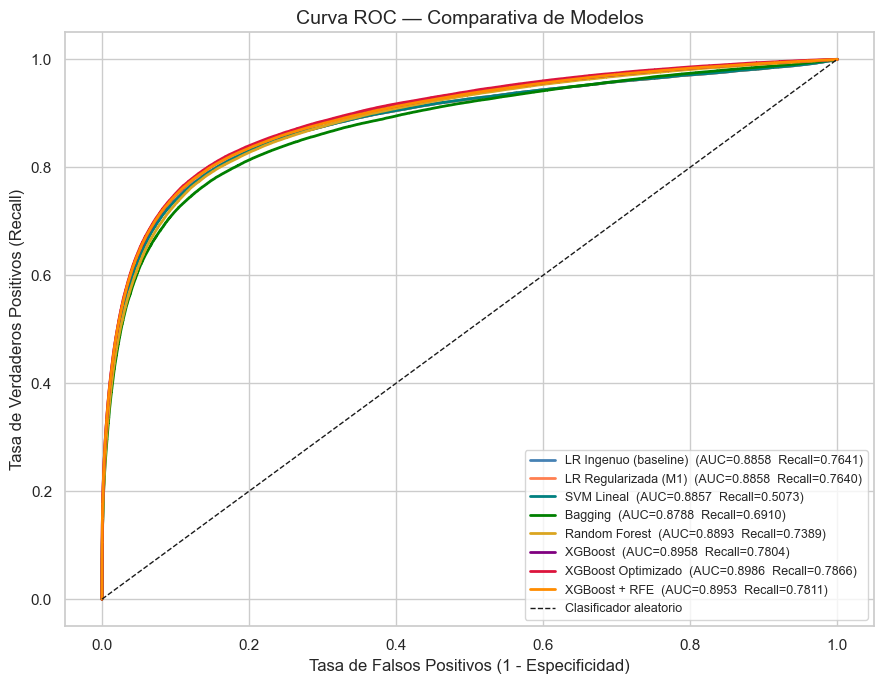

Gráfica guardada como 'roc_comparativa_final.png'


In [29]:
xgb_base_rfe = XGBClassifier(
    n_estimators=100,  # Fijo — suficiente para ranking de features
    max_depth=max_depth_xgb,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    verbosity=0
)

rfe = RFE(
    estimator=xgb_base_rfe,
    n_features_to_select=15,
    step=3,   # Elimina 3 features por iteración → 5 iteraciones totales
    verbose=1
)

pipeline_xgb_rfe = Pipeline(steps=[
    ('preprocessor', preprocessor_xgb),
    ('rfe', rfe),
    ('classifier', XGBClassifier(
        n_estimators=n_estimators_xgb,
        max_depth=max_depth_xgb,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric='auc',
        verbosity=0
    ))
])

evaluar_modelo(
    nombre='XGBoost + RFE',
    pipeline=pipeline_xgb_rfe,
    X_tr=X_train_dev, y_tr=y_train_dev,
    X_te=X_test,      y_te=y_test,
    umbral=0.5
)

# Features seleccionadas
rfe_fitted = pipeline_xgb_rfe.named_steps['rfe']
feature_names = (
    numeric_features +
    list(pipeline_xgb_rfe.named_steps['preprocessor']
         .named_transformers_['cat'].get_feature_names_out(categorical_features)) +
    bool_features
)
features_seleccionadas = [f for f, s in zip(feature_names, rfe_fitted.support_) if s]
print(f"\nFeatures seleccionadas por RFE ({len(features_seleccionadas)}):")
print(features_seleccionadas)

graficar_roc_comparativa()

---
## Sección 16 — Feature Importance y SHAP

Dos análisis complementarios de importancia de variables sobre el modelo XGBoost + RFE:

**A) Feature Importance (gain):** mide cuánto reduce el error cada variable en los splits del árbol. Rápida y directa, pero puede inflar variables con muchas categorías.

**B) SHAP (SHapley Additive exPlanations):** calcula la contribución marginal de cada feature para cada predicción individual. Más riguroso porque considera interacciones entre variables.

**Cómo leer el SHAP Summary Plot:**
- Cada punto es un registro del test
- Eje X: impacto en la predicción (positivo = empuja hacia "bajo peso")
- Color: valor de la feature (rojo = valor alto, azul = valor bajo)
- Ejemplo: `gestation_weeks` con puntos azules a la izquierda → semanas de gestación **bajas** aumentan el riesgo de bajo peso

C:\Users\eoar9\AppData\Local\Temp\ipykernel_19996\749217625.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature',


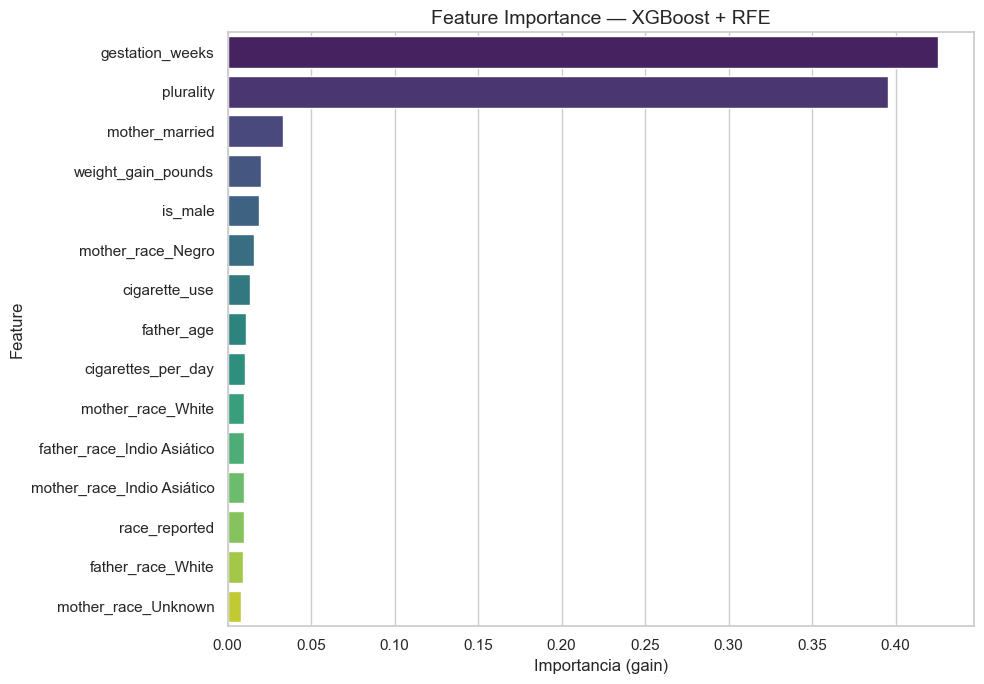

c:\Users\eoar9\Documents\Analitica II\Proyecto Final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


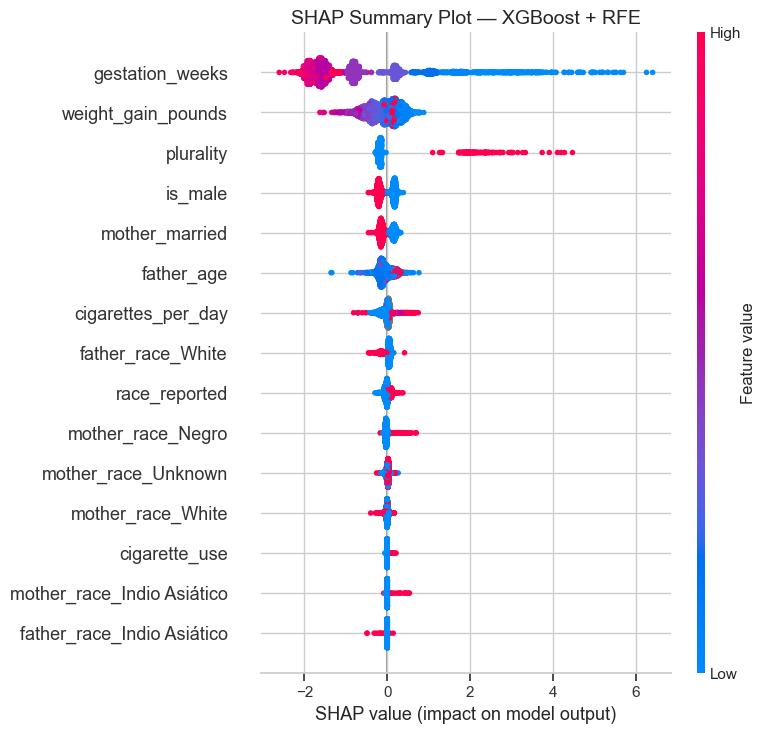

Gráfico SHAP guardado como 'shap_summary_xgb_rfe.png'


In [30]:
xgb_final      = pipeline_xgb_rfe.named_steps['classifier']
preprocessor_f = pipeline_xgb_rfe.named_steps['preprocessor']

X_test_prep   = preprocessor_f.transform(X_test)
X_test_rfe    = rfe_fitted.transform(X_test_prep)
X_test_rfe_df = pd.DataFrame(X_test_rfe, columns=features_seleccionadas).astype('float64')

# --- A) Feature Importance ---
importances   = xgb_final.feature_importances_
importance_df = pd.DataFrame({
    'Feature':    features_seleccionadas,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df, x='Importance', y='Feature',
            orient='h', palette='viridis')
plt.title('Feature Importance — XGBoost + RFE', fontsize=14)
plt.xlabel('Importancia (gain)')
plt.tight_layout()
plt.savefig('feature_importance_xgb_rfe.png', dpi=150)
plt.show()

# --- B) SHAP Summary Plot ---
try:
    import shap
    explainer = shap.TreeExplainer(xgb_final)
    muestra_shap = X_test_rfe_df.sample(min(5000, len(X_test_rfe_df)), random_state=42)
    shap_values  = explainer(muestra_shap)

    plt.figure()
    shap.summary_plot(shap_values, muestra_shap,
                      feature_names=features_seleccionadas, show=False)
    plt.title('SHAP Summary Plot — XGBoost + RFE', fontsize=14)
    plt.tight_layout()
    plt.savefig('shap_summary_xgb_rfe.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Gráfico SHAP guardado como 'shap_summary_xgb_rfe.png'")
except ImportError:
    print("SHAP no instalado. Correr: pip install shap")

---
## Comparativa Final de Modelos

Resumen de resultados del análisis de desarrollo (1% del train). Los resultados definitivos se obtienen con `SAMPLE_FRAC = 1.0`.


COMPARATIVA FINAL DE MODELOS
Modelo                              AUC   Recall   Umbral
-----------------------------------------------------------------
XGBoost Optimizado               0.8986   0.7866     0.50
XGBoost                          0.8958   0.7804     0.50
XGBoost + RFE                    0.8953   0.7811     0.50
Random Forest                    0.8893   0.7389     0.50
LR Regularizada (M1)             0.8858   0.7640     0.50
LR Ingenuo (baseline)            0.8858   0.7641     0.50
SVM Lineal                       0.8857   0.5073     0.30
Bagging                          0.8788   0.6910     0.50

Nota: resultados con SAMPLE_FRAC=0.01 (1% del train).
Correr con SAMPLE_FRAC=1.0 para resultados definitivos.


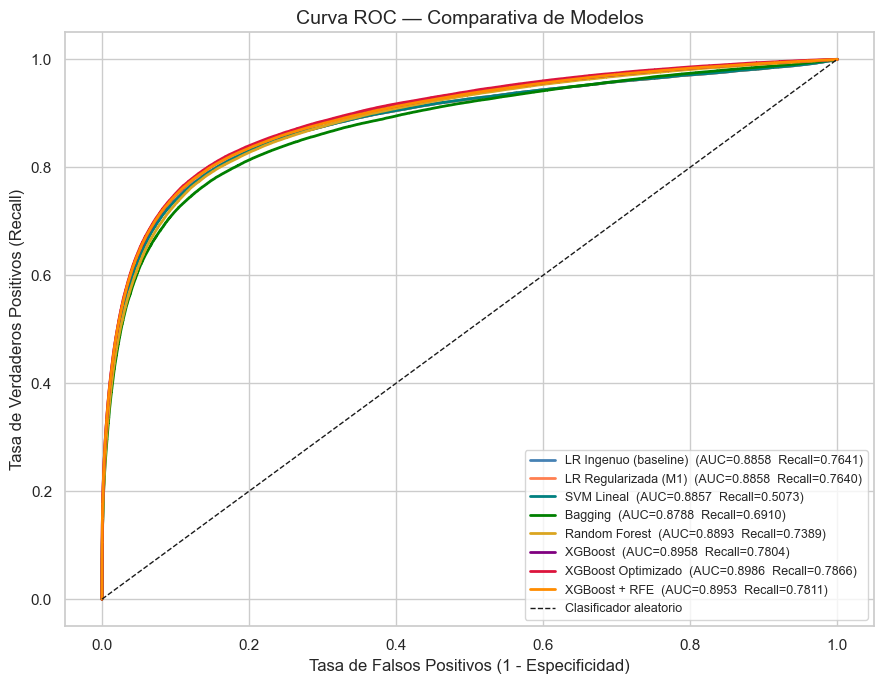

Gráfica guardada como 'roc_comparativa_final.png'


In [31]:
print("\n" + "="*65)
print("COMPARATIVA FINAL DE MODELOS")
print("="*65)
print(f"{'Modelo':<30} {'AUC':>8} {'Recall':>8} {'Umbral':>8}")
print("-"*65)
for nombre, vals in sorted(resultados.items(), key=lambda x: x[1]['auc'], reverse=True):
    print(f"{nombre:<30} {vals['auc']:>8.4f} {vals['recall']:>8.4f} {vals['umbral']:>8.2f}")
print("="*65)
print("\nNota: resultados con SAMPLE_FRAC=0.01 (1% del train).")
print("Correr con SAMPLE_FRAC=1.0 para resultados definitivos.")

graficar_roc_comparativa()